# YOLOv11n-CDL Reproduction + Low-Light Robustness Extension — RDD2022

Reconstructed per `YOLOv11n-CDL_reconstruction_spec.md` (architecture, data protocol,
training, evaluation, extension) and the accompanying agent brief. Built on the
download/extract/VOC-to-YOLO logic from `RDD2022_YOLOv11_Baseline_Improvement.ipynb`.

**Research question:** does CDL's design (ConvSmart + DSA + P2 head) make YOLOv11n more
robust to low light than stock YOLOv11n, does low-light training augmentation help, and can a
learned illumination-correction module (AGE-style gamma) add further robustness?

**Model ladder (cumulative):**

| Row | Adds |
|---|---|
| R1 Baseline | stock YOLOv11n |
| R2 CDL | ConvSmart + DSA + P2 head (the paper's method) |
| R3 CDL + aug | + low-light training augmentation |
| R4 CDL + AGE + aug | + naive AGE (image-space gamma, identity-initialized, range [0.5, 1.5]) |
| R5 CDL + gated AGE + aug | + brightness gate on AGE (**final model**) |

**Runtime:** Colab free tier (T4). Single seed per model.

**Ground rules:**
1. Every `[DECISION]` is appended to `decisions_log.md` on Drive.
2. Test splits are evaluated once per final model and never used for checkpoint selection.
   (Exception, disclosed in Limitations: R5's gate was designed after inspecting R4's results.)
3. All runs use identical settings except the one thing each row adds.
4. No numbers are invented; failed or skipped runs are stated explicitly.
5. Every training/data cell is idempotent and safe to re-run after a Colab disconnect.

## 0. Setup

Pin every version in the first cell (spec ground rule 8): `ultralytics`, `torch`,
`albumentations`. Record the exact resolved versions in `decisions_log.md`.

In [ ]:
PINS = {"ultralytics": "8.3.152", "albumentations": "1.4.18"}
!pip install -q "ultralytics=={PINS['ultralytics']}" "albumentations=={PINS['albumentations']}" --no-deps
!pip install -q "albucore==0.0.17" "eval-type-backport"

import ultralytics, torch, albumentations, torchvision
ultralytics.checks()
print("ultralytics:", ultralytics.__version__)
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("torchvision:", torchvision.__version__)
print("albumentations:", albumentations.__version__)

RESOLVED_VERSIONS = {
    "ultralytics": ultralytics.__version__,
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "albumentations": albumentations.__version__,
}

Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)
ultralytics: 8.3.152
torch: 2.11.0+cu128 | CUDA available: True
torchvision: 0.26.0+cu128
albumentations: 1.4.18


In [ ]:
# Mount Drive so every checkpoint, dataset artifact, and log survives a session disconnect.
from google.colab import drive
drive.mount('/content/drive')

import os, json
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/rdd2022_project')
for sub in ['frozen_split', 'test_dark_mild', 'test_dark_severe', 'runs', 'figures']:
    (PROJECT_DIR / sub).mkdir(parents=True, exist_ok=True)
os.chdir('/content')

DECISIONS_LOG = PROJECT_DIR / 'decisions_log.md'

def log_decision(item, choice, reason):
    # Append one row to decisions_log.md. Idempotent-ish: dedupes on `item`.
    header = "| item | choice | reason |\n|---|---|---|\n"
    row = f"| {item} | {choice} | {reason} |\n"
    if DECISIONS_LOG.exists():
        existing = DECISIONS_LOG.read_text()
        if f"| {item} |" in existing:
            return  # already logged
        with open(DECISIONS_LOG, 'a') as f:
            f.write(row)
    else:
        with open(DECISIONS_LOG, 'w') as f:
            f.write("# Decisions log\n\n" + header + row)

log_decision(
    "pinned versions",
    json.dumps(RESOLVED_VERSIONS),
    "ground rule 8 — record exact resolved versions once, at the top of the run",
)
print(DECISIONS_LOG.read_text())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
# Decisions log

| item | choice | reason |
|---|---|---|
| pinned versions | {"ultralytics": "8.3.152", "torch": "2.11.0+cu128", "albumentations": "1.4.18"} | ground rule 8 — record exact resolved versions once, at the top of the run |
| filename prefix bug | use loop variable `src` directly instead of img_path.parent.parent.parent.name | old logic depended on zip nesting depth, which RDD2022 releases don't keep consistent |
| pool size / split method | ~4,000 images (3,200/400/400), contiguous blocks of sorted filenames per country | spec Section 2 fixes #2 and #3 — smaller pool for 3-day Colab budget; contiguous blocks reduce (not eliminate) near-duplicate-frame leakage vs random shuffling |
| keep_c2psa | kept (reading (a): SPPF -> C2PSA -> DSA) | spec 4.2 default; Table 1's 3.3M param figure for +CD is closer to backbone+C2PSA+DSA than to C2PSA removed —

## Phase 0 — Data (spec Section 2)

Reused from the existing notebook: structure-agnostic XML/image pairing by filename stem,
VOC-to-YOLO conversion, proportional per-country sampling.

**Fixed per spec Section 2, ground rule "required fixes":**
1. Output filename prefix now comes directly from the `src` loop variable instead of
   `img_path.parent.parent.parent.name` (which silently breaks if the zip's internal
   nesting differs — RDD2022 zips are not laid out identically release to release, as the
   original notebook's own sanity-check cell already warns).
2. Pool size cut from 10,000 to **~4,000**: 3,200 train / 400 val / 400 test.
3. Split within each country by **contiguous blocks of sorted filenames**, not random
   shuffling — reduces (does not eliminate) leakage from near-duplicate consecutive frames.
   This is a stated limitation, not a fix: state it again in the report's limitations
   section.
4. The split is frozen after this phase runs once: file lists go to
   `frozen_split/*.txt` and the whole YOLO folder is zipped to Drive. Nothing downstream
   ever regenerates it.
5. Per-class instance counts are printed per split, in addition to per-image counts.

In [ ]:
import requests
from pathlib import Path

RAW_DIR = Path('/content/data/raw')
RAW_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR = RAW_DIR / 'RDD2022_extracted'
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

SOURCES = ['Japan', 'India', 'Czech', 'Norway', 'United_States', 'China_MotorBike', 'China_Drone']

ARTICLE_ID = 21431547  # Figshare article: RDD2022 - CRDDC'2022 multi-national Road Damage Dataset
API_URL = f'https://api.figshare.com/v2/articles/{ARTICLE_ID}'

print('Querying Figshare API for current download link...')
resp = requests.get(API_URL, timeout=60)
resp.raise_for_status()
meta = resp.json()

files = meta.get('files', [])
print(f'Found {len(files)} files on this Figshare record:')
for f in files:
    print(f"  {f['name']}  ({f['size']/1e6:.1f} MB)")

zip_entry = next((f for f in files if f['name'].lower().endswith('.zip')), None)
if zip_entry is None:
    raise RuntimeError(
        'No .zip found on the Figshare record. Check the article page manually: '
        'https://doi.org/10.6084/m9.figshare.21431547'
    )

zip_path = RAW_DIR / zip_entry['name']
download_url = zip_entry['download_url']
print(f"\nDownloading {zip_entry['name']} ({zip_entry['size']/1e9:.2f} GB) from {download_url}")
print('(this is the full 6-country archive — expect this to take a while)')

with requests.get(download_url, stream=True, timeout=300) as r:
    r.raise_for_status()
    total = int(r.headers.get('content-length', zip_entry['size']))
    downloaded = 0
    chunk_size = 1 << 20  # 1 MB
    next_report = 500_000_000  # report every ~500MB
    with open(zip_path, 'wb') as out:
        for chunk in r.iter_content(chunk_size=chunk_size):
            if not chunk:
                continue
            out.write(chunk)
            downloaded += len(chunk)
            if downloaded >= next_report:
                print(f'  {downloaded/1e9:.2f} / {total/1e9:.2f} GB')
                next_report += 500_000_000

print(f'\nDownload complete: {zip_path.stat().st_size/1e9:.2f} GB at {zip_path}')

Querying Figshare API for current download link...
Found 4 files on this Figshare record:
  RDD2022_released_through_CRDDC2022.zip  (13264.2 MB)
  Directory_Structure_CRDDC_RDD2022.txt  (0.0 MB)
  File_List_CRDDC_RDD2022.txt  (3.3 MB)
  label_map.pbtxt  (0.0 MB)

(this is the full 6-country archive — expect this to take a while)
  0.50 / 13.26 GB
  1.00 / 13.26 GB
  1.50 / 13.26 GB
  2.00 / 13.26 GB
  2.50 / 13.26 GB
  3.00 / 13.26 GB
  3.50 / 13.26 GB
  4.00 / 13.26 GB
  4.50 / 13.26 GB
  5.00 / 13.26 GB
  5.50 / 13.26 GB
  6.00 / 13.26 GB
  6.50 / 13.26 GB
  7.00 / 13.26 GB
  7.50 / 13.26 GB
  8.00 / 13.26 GB
  8.50 / 13.26 GB
  9.00 / 13.26 GB
  9.50 / 13.26 GB
  10.00 / 13.26 GB
  10.50 / 13.26 GB
  11.00 / 13.26 GB
  11.50 / 13.26 GB
  12.00 / 13.26 GB
  12.50 / 13.26 GB
  13.00 / 13.26 GB

Download complete: 13.26 GB at /content/data/raw/RDD2022_released_through_CRDDC2022.zip


In [ ]:
import zipfile
print("valid zip:", zipfile.is_zipfile(zip_path))
with zipfile.ZipFile(zip_path) as zf:
    names = zf.namelist()
    print(len(names), "entries; first few:", names[:5])
    print("top-level entries:", sorted({n.split('/')[0] for n in names})[:20])
    zf.extractall(EXTRACT_DIR)   # takes several minutes
print("children of EXTRACT_DIR:", [p.name for p in EXTRACT_DIR.glob('*')])
print("zips at depth 1-2:", [str(p.relative_to(EXTRACT_DIR)) for p in
      list(EXTRACT_DIR.glob('*.zip')) + list(EXTRACT_DIR.glob('*/*.zip'))])

valid zip: True
7 entries; first few: ['RDD2022/China_Drone.zip', 'RDD2022/China_MotorBike.zip', 'RDD2022/Czech.zip', 'RDD2022/India.zip', 'RDD2022/Japan.zip']
top-level entries: ['RDD2022']
children of EXTRACT_DIR: ['RDD2022']
zips at depth 1-2: ['RDD2022/Norway.zip', 'RDD2022/Japan.zip', 'RDD2022/India.zip', 'RDD2022/China_MotorBike.zip', 'RDD2022/Czech.zip', 'RDD2022/China_Drone.zip', 'RDD2022/United_States.zip']


In [ ]:
import zipfile
from pathlib import Path

inner_dir = EXTRACT_DIR / 'RDD2022'
print('Inner zips found:')
inner_zips = sorted(inner_dir.glob('*.zip'))
for z in inner_zips:
    print(f'  {z.name}  ({z.stat().st_size/1e6:.1f} MB)')

for z in inner_zips:
    # matches "Japan.zip" -> "Japan", "China_Drone.zip" -> "China_Drone", etc.
    src_name = z.stem
    out_dir = inner_dir / src_name
    print(f'Extracting {z.name} -> {out_dir} ...')
    if not zipfile.is_zipfile(z):
        print(f'  WARNING: {z.name} is not a valid zip, skipping')
        continue
    with zipfile.ZipFile(z, 'r') as zf:
        zf.extractall(out_dir)
    z.unlink()  # free disk space once extracted

print('\nDone extracting inner zips.')

Inner zips found:
  China_Drone.zip  (160.2 MB)
  China_MotorBike.zip  (192.0 MB)
  Czech.zip  (257.1 MB)
  India.zip  (526.7 MB)
  Japan.zip  (1072.6 MB)
  Norway.zip  (10611.2 MB)
  United_States.zip  (444.3 MB)
Extracting China_Drone.zip -> /content/data/raw/RDD2022_extracted/RDD2022/China_Drone ...
Extracting China_MotorBike.zip -> /content/data/raw/RDD2022_extracted/RDD2022/China_MotorBike ...
Extracting Czech.zip -> /content/data/raw/RDD2022_extracted/RDD2022/Czech ...
Extracting India.zip -> /content/data/raw/RDD2022_extracted/RDD2022/India ...
Extracting Japan.zip -> /content/data/raw/RDD2022_extracted/RDD2022/Japan ...
Extracting Norway.zip -> /content/data/raw/RDD2022_extracted/RDD2022/Norway ...
Extracting United_States.zip -> /content/data/raw/RDD2022_extracted/RDD2022/United_States ...

Done extracting inner zips.


In [ ]:
FROZEN_MARKER = PROJECT_DIR / 'frozen_split' / '_frozen.json'
print(FROZEN_MARKER, "| exists:", FROZEN_MARKER.exists())

/content/drive/MyDrive/rdd2022_project/frozen_split/_frozen.json | exists: True


In [ ]:
# Structure sanity check (kept from the existing notebook) — RDD2022 zips are not
# laid out identically release to release, so we inspect rather than assume.
def print_tree(path, prefix='', max_depth=4, depth=0):
    path = Path(path)
    if depth > max_depth:
        return
    if not path.exists():
        print(f'{prefix}(missing: {path})')
        return
    entries = sorted(path.iterdir())
    for d in [e for e in entries if e.is_dir()]:
        print(f'{prefix}{d.name}/')
        print_tree(d, prefix + '  ', max_depth, depth + 1)
    files = [e for e in entries if e.is_file()]
    for f in files[:3]:
        print(f'{prefix}{f.name}')
    if len(files) > 3:
        print(f'{prefix}... ({len(files)} files total)')

if not FROZEN_MARKER.exists():
    print('--- Japan ---')
    print_tree(RAW_DIR / 'Japan')

### Build the ~4,000-image pool: country-stratified, contiguous-block 3,200/400/400 split

Each source folder is sampled proportionally to its share of the usable RDD2022 pairs
(structure-agnostic pairing: every `.xml` matched to an image of the same stem anywhere
under that source's folder). **[DECISION, spec Section 2 fix #1]** the YOLO-format output
filename is now `f"{src}_{img_path.name}"` — `src` is the loop variable, not a path
component — so the prefix can never silently depend on how deep a given release nests its
files. **[DECISION, fix #3]** within each country, images are sorted by filename and split
into contiguous blocks (train block, then val block, then test block) instead of shuffled,
to reduce (not eliminate) leakage between near-duplicate consecutive dashcam frames.

In [ ]:
import xml.etree.ElementTree as ET
import shutil

OUT_DIR = Path('/content/data/yolo')
for split in ['train', 'val', 'test']:
    (OUT_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (OUT_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

CLASSES = ['D00', 'D10', 'D20', 'D40']
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}

POOL_SIZE = 4000                     # spec fix #2 (was 10,000)
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.80, 0.10, 0.10   # -> 3,200 / 400 / 400

def voc_to_yolo_line(obj, img_w, img_h):
    name = obj.find('name').text
    if name not in CLASS_TO_ID:
        return None
    cls_id = CLASS_TO_ID[name]
    bb = obj.find('bndbox')
    xmin, ymin = float(bb.find('xmin').text), float(bb.find('ymin').text)
    xmax, ymax = float(bb.find('xmax').text), float(bb.find('ymax').text)
    xc, yc = ((xmin + xmax) / 2) / img_w, ((ymin + ymax) / 2) / img_h
    w, h = (xmax - xmin) / img_w, (ymax - ymin) / img_h
    return f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}"

def collect_pairs(source_dir):
    # Structure-agnostic: every *.xml under source_dir, paired to an image of the
    # same stem anywhere under source_dir. Kept verbatim from the existing notebook.
    source_dir = Path(source_dir)
    if not source_dir.exists():
        print(f"WARNING: {source_dir} does not exist — extraction may have failed")
        return []
    xml_paths = list(source_dir.rglob('*.xml'))
    if not xml_paths:
        print(f"WARNING: no .xml files found under {source_dir}")
        return []
    img_by_stem = {}
    for ext in ('*.jpg', '*.jpeg', '*.JPG', '*.png'):
        for img_path in source_dir.rglob(ext):
            img_by_stem[img_path.stem] = img_path
    pairs = []
    for xml_path in xml_paths:
        img_path = img_by_stem.get(xml_path.stem)
        if img_path is None:
            continue
        tree = ET.parse(xml_path)
        if any(o.find('name').text in CLASS_TO_ID for o in tree.getroot().findall('object')):
            pairs.append((img_path, xml_path))
    return pairs

if FROZEN_MARKER.exists():
    print("Frozen split already exists — not rebuilding the pool (spec: never regenerate).")
else:
    per_source_pairs = {src: collect_pairs(RAW_DIR / src) for src in SOURCES}
    for src, pairs in per_source_pairs.items():
        print(f"{src}: {len(pairs)} usable image/annotation pairs")
    total_available = sum(len(v) for v in per_source_pairs.values())
    print(f"\nTotal usable pairs across all sources: {total_available}")
    if total_available == 0:
        raise RuntimeError(
            "No usable pairs found. Check the structure sanity-check cell above: did the "
            "zips actually extract? Do image filenames match .xml stems exactly?"
        )

    # Sort (not shuffle) each source by filename, then take a proportional, contiguous
    # slice — contiguous at the SOURCE level too, so we're not interleaving the sampling
    # step with the split step in a way that reintroduces randomness fix #3 is meant to avoid.
    pool_per_source = {}
    for src, pairs in per_source_pairs.items():
        pairs_sorted = sorted(pairs, key=lambda p: p[0].name)
        share = len(pairs_sorted) / total_available
        target = round(POOL_SIZE * share)
        # take an evenly-spaced sample of `target` items from the sorted list so we don't
        # just grab the alphabetically-first block of one source
        if target >= len(pairs_sorted):
            sample = pairs_sorted
        else:
            step = len(pairs_sorted) / target
            idxs = sorted(set(int(i * step) for i in range(target)))
            sample = [pairs_sorted[i] for i in idxs]
        pool_per_source[src] = sorted(sample, key=lambda p: p[0].name)  # re-sort: contiguous blocks need sorted order
        print(f"{src}: sampled {len(pool_per_source[src])} / {len(pairs_sorted)} (target share {share:.3f})")

    splits = {'train': [], 'val': [], 'test': []}
    for src, pairs in pool_per_source.items():
        n = len(pairs)
        n_train = int(n * TRAIN_FRAC)
        n_val = int(n * VAL_FRAC)
        # CONTIGUOUS BLOCKS of sorted filenames — fix #3
        splits['train'] += pairs[:n_train]
        splits['val'] += pairs[n_train:n_train + n_val]
        splits['test'] += pairs[n_train + n_val:]

    for split_name, pairs in splits.items():
        print(f"{split_name}: {len(pairs)} images")

Frozen split already exists — not rebuilding the pool (spec: never regenerate).


In [ ]:
from PIL import Image
from collections import defaultdict

if FROZEN_MARKER.exists():
    print("Frozen split already exists — skipping conversion.")
else:
    per_country_out_counts = defaultdict(lambda: defaultdict(int))
    per_class_instance_counts = defaultdict(lambda: defaultdict(int))  # [split][class] -> count

    for split, pairs in splits.items():
        for img_path, xml_path in pairs:
            with Image.open(img_path) as im:
                w, h = im.size
            tree = ET.parse(xml_path)
            lines = []
            for obj in tree.getroot().findall('object'):
                line = voc_to_yolo_line(obj, w, h)
                if line:
                    lines.append(line)
                    cls_name = CLASSES[int(line.split()[0])]
                    per_class_instance_counts[split][cls_name] += 1
            if not lines:
                continue
            # FIX #1: prefix comes from the loop variable `src` directly, not from
            # img_path's ancestor folder names (which depend on zip nesting).
            src = None
            for cand in per_source_pairs:
                # cheap membership check against the (unsampled) per-source pair lists
                pass
            # we know which source this pair came from because pool_per_source is keyed by src
            out_name = None
            for cand_src, cand_pairs in pool_per_source.items():
                if (img_path, xml_path) in cand_pairs:
                    src = cand_src
                    break
            assert src is not None, f"could not trace {img_path} back to a source folder"
            out_name = f"{src}_{img_path.name}"
            shutil.copy(img_path, OUT_DIR / 'images' / split / out_name)
            with open(OUT_DIR / 'labels' / split / (Path(out_name).stem + '.txt'), 'w') as f:
                f.write('\n'.join(lines))
            per_country_out_counts[split][src] += 1

    print('Done converting to YOLO format.')
    for split in ['train', 'val', 'test']:
        n_imgs = len(list((OUT_DIR / 'images' / split).glob('*.jpg')))
        print(split, ':', n_imgs, 'images')

    # ASSERTION required by spec fix #1: per-country output file counts must equal the
    # per-country split counts we intended to write.
    for split, pairs in splits.items():
        intended = defaultdict(int)
        for img_path, xml_path in pairs:
            for cand_src, cand_pairs in pool_per_source.items():
                if (img_path, xml_path) in cand_pairs:
                    intended[cand_src] += 1
                    break
        for src in SOURCES:
            # some pairs are dropped if they have zero usable objects (per-class filter),
            # so compare against actual written labels, not the pre-filter pair count
            written = per_country_out_counts[split].get(src, 0)
            print(f"  [{split}] {src}: intended (pre-empty-label-filter)={intended.get(src,0)}, written={written}")

Frozen split already exists — skipping conversion.


In [ ]:
if not FROZEN_MARKER.exists():
    import pandas as pd

    print("=== Per-class instance counts per split ===")
    class_df = pd.DataFrame(per_class_instance_counts).fillna(0).astype(int)
    class_df = class_df.reindex(CLASSES)
    print(class_df)

    print("\n=== Per-country image counts per split ===")
    country_df = pd.DataFrame(per_country_out_counts).fillna(0).astype(int)
    country_df = country_df.reindex(SOURCES)
    print(country_df)

    near_absent = []
    for split in ['val', 'test']:
        for cls in CLASSES:
            if class_df.loc[cls, split] < 5:
                near_absent.append((split, cls, int(class_df.loc[cls, split])))
    if near_absent:
        print("\nFLAG — classes nearly absent from val/test (n<5):", near_absent)
    else:
        print("\nNo class is near-absent (<5 instances) in val or test.")

    class_df.to_csv(PROJECT_DIR / 'frozen_split' / 'per_class_instance_counts.csv')
    country_df.to_csv(PROJECT_DIR / 'frozen_split' / 'per_country_image_counts.csv')

In [ ]:
# --- Freeze the split: file lists + zip to Drive. Never regenerated after this runs. ---
import json as _json

if FROZEN_MARKER.exists():
    print("Already frozen.")
else:
    for split in ['train', 'val', 'test']:
        names = sorted(p.name for p in (OUT_DIR / 'images' / split).glob('*.jpg'))
        with open(PROJECT_DIR / 'frozen_split' / f'{split}_files.txt', 'w') as f:
            f.write('\n'.join(names))

    zip_path = PROJECT_DIR / 'frozen_split' / 'rdd2022_yolo_4k.zip'
    if not zip_path.exists():
        shutil.make_archive(str(zip_path.with_suffix('')), 'zip', OUT_DIR)
        print('Zipped frozen dataset to', zip_path)

    with open(FROZEN_MARKER, 'w') as f:
        _json.dump({
            "pool_size": POOL_SIZE,
            "train_frac": TRAIN_FRAC, "val_frac": VAL_FRAC, "test_frac": TEST_FRAC,
            "split_method": "contiguous_blocks_per_country_sorted_by_filename",
        }, f, indent=2)

    log_decision(
        "filename prefix bug",
        "use loop variable `src` directly instead of img_path.parent.parent.parent.name",
        "old logic depended on zip nesting depth, which RDD2022 releases don't keep consistent",
    )
    log_decision(
        "pool size / split method",
        "~4,000 images (3,200/400/400), contiguous blocks of sorted filenames per country",
        "spec Section 2 fixes #2 and #3 — smaller pool for 3-day Colab budget; contiguous "
        "blocks reduce (not eliminate) near-duplicate-frame leakage vs random shuffling",
    )
    print("Split frozen. Re-run cells above only after manually deleting", FROZEN_MARKER)

Already frozen.


In [ ]:
# data.yaml for the frozen split (unpacks the zip if this is a fresh session)
if not any((OUT_DIR / 'images' / 'train').glob('*.jpg')):
    print("Unpacking frozen dataset from Drive (fresh session)...")
    shutil.unpack_archive(str(PROJECT_DIR / 'frozen_split' / 'rdd2022_yolo_4k.zip'), str(OUT_DIR))

data_yaml_text = f'''
path: /content/data/yolo
train: images/train
val: images/val
test: images/test
names:
  0: D00
  1: D10
  2: D20
  3: D40
'''
DATA_YAML = '/content/data/rdd2022.yaml'
with open(DATA_YAML, 'w') as f:
    f.write(data_yaml_text)
print(data_yaml_text)

Unpacking frozen dataset from Drive (fresh session)...

path: /content/data/yolo
train: images/train
val: images/val
test: images/test
names:
  0: D00
  1: D10
  2: D20
  3: D40



In [ ]:
for sp in ['train', 'val', 'test']:
    print(sp, len(list((OUT_DIR/'images'/sp).glob('*.jpg'))), len(list((OUT_DIR/'labels'/sp).glob('*.txt'))))

train 3198 3198
val 398 398
test 403 403


## Phase 1 — Modules (spec Sections 4 and 6)

`ConvSmart` and `DSA` are implemented once in a shared `common.py`, saved to Drive, and
imported by every later cell/run — never redefined per-model. Both are registered into
`ultralytics.nn.tasks.parse_model` so YAML files can reference them by name.

In [ ]:
# --- Write the shared module file to Drive. All notebooks/runs import from here. ---
COMMON_PY = r'''
# common.py — shared modules and utilities for the YOLOv11n-CDL reconstruction project.
# Import this from every notebook / training script so ConvSmart, DSA, the augmentation
# pipelines, and the dark-set generator are identical everywhere. Source of truth for the
# module math: YOLOv11n-CDL_reconstruction_spec.md, Sections 4 and 10.

import re
import inspect
import random
import numpy as np
import torch
import torch.nn as nn


# ----------------------------------------------------------------------------
# 4.1 ConvSmart (spec Sec 4.1, Eqs 1-6, Fig 3)
# ----------------------------------------------------------------------------
class ConvSmart(nn.Module):
    # F1 = Conv3x3(X)              # ceil(c2/2) channels, standard conv, no bias
    # F2 = Conv5x5(X)               # floor(c2/2) channels, standard conv, no bias
    # F_merge = concat([F1, F2])    # c2 channels
    # F_id = Conv1x1(X)             # c2 channels (residual path)
    # F_sum = F_merge + F_id
    # F_pool = MaxPool2d(k=2, s=2)(F_sum)  if s > 1 else F_sum
    # F_out = SiLU(Norm(F_pool))           # Norm = BN, or IBN if ibn=True
    #
    # Constructor mirrors Ultralytics' Conv(c1, c2, k, s) call convention so YAML args
    # [c2, 3, 2] work through parse_model unmodified. `k` is accepted for YAML compatibility
    # but ignored - kernel sizes are fixed at 3x3/5x5/1x1 per the paper. [DECISION, spec 4.1]
    # odd c2 gives the extra channel to the 3x3 branch. [DECISION, spec 10.2] `ibn=True`
    # replaces the single BN with an Instance/Batch split-norm (IBN-Net style): the first
    # half of channels get InstanceNorm2d(affine=True), the rest get BatchNorm2d.
    def __init__(self, c1, c2, k=3, s=1, ibn=False):
        super().__init__()
        c_3x3 = -(-c2 // 2)   # ceil
        c_5x5 = c2 // 2       # floor
        assert c_3x3 + c_5x5 == c2
        self.conv3 = nn.Conv2d(c1, c_3x3, 3, 1, 1, bias=False)
        self.conv5 = nn.Conv2d(c1, c_5x5, 5, 1, 2, bias=False)
        self.conv1 = nn.Conv2d(c1, c2, 1, 1, 0, bias=False)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) if s and s > 1 else nn.Identity()
        self.ibn = bool(ibn)
        if self.ibn:
            self.in_ch = c2 // 2
            self.bn_ch = c2 - self.in_ch
            self.inorm = nn.InstanceNorm2d(self.in_ch, affine=True)
            self.bnorm = nn.BatchNorm2d(self.bn_ch)
        else:
            self.norm = nn.BatchNorm2d(c2)
        self.act = nn.SiLU()
        self.c1, self.c2, self.s = c1, c2, s

    def forward(self, x):
        f1 = self.conv3(x)
        f2 = self.conv5(x)
        f_merge = torch.cat([f1, f2], dim=1)
        f_id = self.conv1(x)
        f_sum = f_merge + f_id
        f_pool = self.pool(f_sum)
        if self.ibn:
            a, b = torch.split(f_pool, [self.in_ch, self.bn_ch], dim=1)
            f_norm = torch.cat([self.inorm(a), self.bnorm(b)], dim=1)
        else:
            f_norm = self.norm(f_pool)
        return self.act(f_norm)


# ----------------------------------------------------------------------------
# 4.2 DSA — Double-Stage Attention (spec Sec 4.2, Eqs 7-10, Fig 4)
# ----------------------------------------------------------------------------
class SEBlock(nn.Module):
    # Standard Squeeze-and-Excitation: GAP -> FC-ReLU-FC-Sigmoid (r=16, min 4 hidden
    # units) -> reweight input. [DECISION, spec 4.2] output is the reweighted feature map,
    # not just the gate.
    def __init__(self, c, r=16):
        super().__init__()
        hidden = max(c // r, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(c, hidden, 1)
        self.fc2 = nn.Conv2d(hidden, c, 1)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        w = self.sigmoid(self.fc2(self.relu(self.fc1(self.pool(x)))))
        return x * w


class SpatialAttention(nn.Module):
    # CBAM-style: channel-wise mean+max -> concat (2ch) -> 7x7 conv -> sigmoid ->
    # reweight input. [DECISION, spec 4.2] - paper cites Mnih 2014 / Xue 2021 without
    # giving an explicit form.
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, 1, k // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        w = self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * w


class DSA(nn.Module):
    # Channel-preserving: (B,C,H,W) -> (B,C,H,W).
    # Stage 1 (parallel):  X_SE1 = SE(X)              X_SP1 = SpatialAttention(X)
    # Stage 2 (fuse):      X1 = Conv1x1(concat[X_SE1, X_SP1])          # 2C -> C
    # Stage 3 (cross-fed): X_SE2 = SE(X1 + X_SP1)     X_SP2 = SpatialAttention(X1 + X_SE1)
    # Final fusion:        X_out = Conv1x1(concat[X_SE2, X_SP2])       # 2C -> C
    # [DECISION, spec 4.2] the two 1x1 fusion convs are Conv+BN+SiLU (unspecified in the
    # paper). YAML arg (e.g. 1024) is accepted but ignored: DSA is channel-preserving and
    # c1 always equals c2 for this module (see parse_model registration notes, spec Sec 6).
    def __init__(self, c1, c2=None, *args):
        super().__init__()
        c = c1
        self.se1, self.sp1 = SEBlock(c), SpatialAttention()
        self.fuse1 = nn.Sequential(nn.Conv2d(2 * c, c, 1, bias=False), nn.BatchNorm2d(c), nn.SiLU())
        self.se2, self.sp2 = SEBlock(c), SpatialAttention()
        self.fuse2 = nn.Sequential(nn.Conv2d(2 * c, c, 1, bias=False), nn.BatchNorm2d(c), nn.SiLU())

    def forward(self, x):
        x_se1, x_sp1 = self.se1(x), self.sp1(x)
        x1 = self.fuse1(torch.cat([x_se1, x_sp1], dim=1))
        x_se2 = self.se2(x1 + x_sp1)
        x_sp2 = self.sp2(x1 + x_se1)
        return self.fuse2(torch.cat([x_se2, x_sp2], dim=1))


# ----------------------------------------------------------------------------
# Registration into ultralytics.nn.tasks.parse_model (spec Section 6)
# ----------------------------------------------------------------------------
def register_custom_modules():
    # Idempotent: safe to call any number of times per process (and after importlib.reload).
    #
    # Ultralytics builds modules inside parse_model(); how a module is constructed
    # (which args it receives, how channels propagate) depends on membership in a LOCAL
    # frozenset `base_modules` - not a public registry. We recompile parse_model from its
    # own source with ConvSmart AND DSA added to base_modules, so both receive
    # (c1, c2, *args) with width/max_channels scaling applied:
    #   ConvSmart [c2, 3, s(, ibn)] -> ConvSmart(c1, c2_scaled, 3, s(, ibn))
    #   DSA       [1024]            -> DSA(c1=256, c2=256)   (n scale; channel-preserving)
    # (Leaving DSA out of base_modules would build it as DSA(1024) with the unscaled YAML
    # arg while its input has 256 channels -> shape crash at model build.)
    # Verified against the parse_model source of ultralytics==8.3.152 (pinned in cell 2).
    import ultralytics.nn.tasks as tasks

    tasks.ConvSmart = ConvSmart
    tasks.DSA = DSA
    globals()['ConvSmart'] = ConvSmart
    globals()['DSA'] = DSA

    ns = getattr(tasks, '_cdl_patched_ns', None)
    if ns is not None:
        # Already patched in this process: only refresh the class references the patched
        # function resolves (covers importlib.reload(common) creating new class objects,
        # which would otherwise break pickling of saved checkpoints).
        ns['ConvSmart'] = ConvSmart
        ns['DSA'] = DSA
        return

    src = inspect.getsource(tasks.parse_model)
    patched, n = re.subn(r'(base_modules\s*=\s*frozenset\(\s*\{)',
                         r'\1ConvSmart, DSA, ', src, count=1)
    if n == 0:
        raise RuntimeError(
            "Could not find `base_modules = frozenset({...})` in this Ultralytics version's "
            "parse_model. Print inspect.getsource(ultralytics.nn.tasks.parse_model), add "
            "ConvSmart and DSA to the channel-changing module set by hand, and re-check the "
            "pinned version in cell 2."
        )
    ns = dict(vars(tasks))
    exec(compile(patched, '<parse_model_patched_for_ConvSmart_DSA>', 'exec'), ns)
    tasks.parse_model = ns['parse_model']
    tasks._cdl_patched_ns = ns
    print("Registered ConvSmart and DSA into ultralytics.nn.tasks.parse_model "
          f"(ultralytics {__import__('ultralytics').__version__}).")


# ----------------------------------------------------------------------------
# 10.1 Pipeline A — low-light TRAINING augmentation (R3, R4 only)
# ----------------------------------------------------------------------------
# Photometric only (boxes unchanged). Applied with probability ~0.3 per training image.
# Deliberately different code AND different parameter ranges from pipeline B (spec 10.1,
# 10.3) so the training augmentation and the test corruption are not literally the same
# transform.
import albumentations as A

def build_pipeline_a(p=0.3):
    # Gamma darkening + brightness scale + additive Gaussian/ISO noise + optional mild
    # colour-temperature shift. Used only on TRAIN images, only for R3/R4.
    return A.Compose([
        A.OneOf([
            A.RandomGamma(gamma_limit=(150, 300), p=1.0),          # gamma ~1.5-3.0
            A.RandomBrightnessContrast(brightness_limit=(-0.8, -0.4), contrast_limit=0.1, p=1.0),  # scale ~0.2-0.6
        ], p=1.0),
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
            A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.2, 0.5), p=1.0),
        ], p=0.8),
        A.RGBShift(r_shift_limit=8, g_shift_limit=4, b_shift_limit=-8, p=0.3),  # mild colour-temp shift
    ], p=p)


def install_pipeline_a(trainer_or_model=None):
    # Hook pipeline A into Ultralytics' training-time Albumentations transform by
    # monkey-patching ultralytics.data.augment.Albumentations.__init__. The ORIGINAL
    # __init__ is stashed on the class (survives importlib.reload) so
    # uninstall_pipeline_a() can restore stock behaviour for no-aug runs.
    # NOTE: while installed, Ultralytics' default light Albumentations (Blur/MedianBlur/
    # ToGray/CLAHE at p=0.01) are replaced by pipeline A - note this in the report.
    import ultralytics.data.augment as aug_mod

    if not hasattr(aug_mod, 'Albumentations'):
        raise RuntimeError(
            "This Ultralytics version has no `Albumentations` class in "
            "ultralytics.data.augment - adjust this hook for the pinned version."
        )
    cls = aug_mod.Albumentations
    if not hasattr(cls, '_orig_init_cdl'):
        cls._orig_init_cdl = cls.__init__
    orig_init = cls._orig_init_cdl
    pipeline_a = build_pipeline_a(p=0.3)

    def patched_init(self, p=1.0):
        orig_init(self, p=p)
        self.contains_spatial = False
        self.transform = pipeline_a
        print("pipeline A (low-light training augmentation) installed, p=0.3")

    cls.__init__ = patched_init


def uninstall_pipeline_a():
    # Restore Ultralytics' stock Albumentations __init__ (needed before any no-aug run
    # that follows an aug run in the same session).
    import ultralytics.data.augment as aug_mod
    cls = aug_mod.Albumentations
    if hasattr(cls, '_orig_init_cdl'):
        cls.__init__ = cls._orig_init_cdl
        print("pipeline A uninstalled - stock Ultralytics augmentation restored")
    else:
        print("pipeline A was never installed - nothing to restore")


# ----------------------------------------------------------------------------
# 10.3 Pipeline B — TEST dark-set generator (test_dark_mild / test_dark_severe)
# ----------------------------------------------------------------------------
# Physically motivated, deliberately different code/params from pipeline A. Generated
# ONCE from the frozen test split, fixed seed, saved to disk, never regenerated.
def _srgb_to_linear(img01):
    a = 0.055
    return np.where(img01 <= 0.04045, img01 / 12.92, ((img01 + a) / (1 + a)) ** 2.4)

def _linear_to_srgb(lin):
    a = 0.055
    lin = np.clip(lin, 0, 1)
    return np.where(lin <= 0.0031308, lin * 12.92, (1 + a) * np.power(lin, 1 / 2.4) - a)

def darken_pipeline_b(img_uint8, exposure_scale, poisson_peak=255.0, read_noise_sigma=0.01,
                       rng=None):
    # img_uint8: HxWx3 uint8 RGB. exposure_scale: mild ~0.25, severe ~0.08 (spec 10.3).
    # poisson_peak=255: at 30 the shot noise swamps the signal (mid-gray mild: mean 58,
    # std 30; SNR ~1 for severe), so the test would measure noise more than darkness.
    rng = rng or np.random.default_rng(0)
    img01 = img_uint8.astype(np.float64) / 255.0
    lin = _srgb_to_linear(img01)
    lin_dark = lin * exposure_scale
    # Poisson shot noise (scale-dependent) + Gaussian read noise, then convert back.
    photons = np.clip(lin_dark, 0, 1) * poisson_peak
    noisy_photons = rng.poisson(photons).astype(np.float64)
    noisy_lin = noisy_photons / poisson_peak
    noisy_lin += rng.normal(0, read_noise_sigma, size=noisy_lin.shape)
    noisy_lin = np.clip(noisy_lin, 0, 1)
    out01 = _linear_to_srgb(noisy_lin)
    return np.clip(out01 * 255.0, 0, 255).astype(np.uint8)
'''

COMMON_PY_PATH = PROJECT_DIR / 'common.py'
# common.py is generated by THIS cell, so keep Drive in sync with it. If you edit it after
# any model has been trained, retrain: checkpoints pickle references to these classes.
if (not COMMON_PY_PATH.exists()) or COMMON_PY_PATH.read_text() != COMMON_PY:
    COMMON_PY_PATH.write_text(COMMON_PY)
    print("Wrote/updated", COMMON_PY_PATH)
else:
    print("common.py on Drive already matches this notebook - unchanged.")

import sys
sys.path.insert(0, str(PROJECT_DIR))
import importlib
import common
importlib.reload(common)
from common import (ConvSmart, DSA, register_custom_modules, build_pipeline_a,
                    install_pipeline_a, uninstall_pipeline_a, darken_pipeline_b)

common.py on Drive already matches this notebook - unchanged.


In [ ]:
# --- Unit tests: ConvSmart / DSA shape correctness (spec Phase 1, checklist item 2) ---
import torch

def test_convsmart():
    x = torch.randn(2, 32, 64, 64)
    m = ConvSmart(32, 64, s=1)
    y = m(x)
    assert y.shape == (2, 64, 64, 64), f"s=1 shape wrong: {y.shape}"

    m2 = ConvSmart(32, 64, s=2)
    y2 = m2(x)
    assert y2.shape == (2, 64, 32, 32), f"s=2 shape wrong: {y2.shape}"

    m_odd = ConvSmart(32, 65, s=1)  # odd C_out
    y_odd = m_odd(x)
    assert y_odd.shape == (2, 65, 64, 64), f"odd c_out shape wrong: {y_odd.shape}"
    assert m_odd.conv3.out_channels == 33 and m_odd.conv5.out_channels == 32, "odd split should give the extra channel to the 3x3 branch"

    m_ibn = ConvSmart(32, 64, s=1, ibn=True)
    y_ibn = m_ibn(x)
    assert y_ibn.shape == (2, 64, 64, 64), f"ibn shape wrong: {y_ibn.shape}"
    assert hasattr(m_ibn, 'inorm') and hasattr(m_ibn, 'bnorm')

    print("ConvSmart: all shape tests passed (s=1, s=2, odd c_out, ibn on/off).")
def test_dsa():
    x = torch.randn(2, 128, 20, 20)
    m = DSA(128)
    y = m(x)
    assert y.shape == x.shape, f"DSA should preserve shape, got {y.shape}"
    n_params = sum(p.numel() for p in m.parameters())
    print(f"DSA: shape preserved OK. param count at C=128: {n_params/1e6:.4f}M "
          f"(paper reports ~0.08M total at the model's deepest stage — compare after "
          f"building the full CDL model, this is just the isolated-module count).")

test_convsmart()
test_dsa()

ConvSmart: all shape tests passed (s=1, s=2, odd c_out, ibn on/off).
DSA: shape preserved OK. param count at C=128: 0.0706M (paper reports ~0.08M total at the model's deepest stage — compare after building the full CDL model, this is just the isolated-module count).


In [ ]:
BASELINE_YAML_PATH = '/content/baseline.yaml'   # stock yolo11n.yaml, nc=4 — unchanged

# R2/R3 base architecture: CDL backbone (ConvSmart stem/downsamples, C3k2, SPPF, C2PSA, DSA)
CDL_YAML_TEXT = r'''
nc: 4
scales:
  n: [0.50, 0.25, 1024]

backbone:
  - [-1, 1, ConvSmart,  [64, 3, 2]]         # 0  P1/2 (stem is ConvSmart per Fig. 2)
  - [-1, 1, ConvSmart,  [128, 3, 2]]        # 1  P2/4
  - [-1, 2, C3k2,       [256, False, 0.25]] # 2
  - [-1, 1, ConvSmart,  [256, 3, 2]]        # 3  P3/8
  - [-1, 2, C3k2,       [512, False, 0.25]] # 4
  - [-1, 1, ConvSmart,  [512, 3, 2]]        # 5  P4/16
  - [-1, 2, C3k2,       [512, True]]        # 6
  - [-1, 1, ConvSmart,  [1024, 3, 2]]       # 7  P5/32
  - [-1, 2, C3k2,       [1024, True]]       # 8
  - [-1, 1, SPPF,       [1024, 5]]          # 9
  - [-1, 2, C2PSA,      [1024]]             # 10
  - [-1, 1, DSA,        [1024]]             # 11

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 12
  - [[-1, 6], 1, Concat, [1]]                   # 13
  - [-1, 2, C3k2, [512, False]]                 # 14

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 15
  - [[-1, 4], 1, Concat, [1]]                   # 16
  - [-1, 2, C3k2, [256, False]]                 # 17

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 18
  - [[-1, 2], 1, Concat, [1]]                   # 19
  - [-1, 2, C3k2, [128, False]]                 # 20

  - [-1, 1, ConvSmart, [128, 3, 2]]             # 21
  - [[-1, 17], 1, Concat, [1]]                  # 22
  - [-1, 2, C3k2, [256, False]]                 # 23

  - [-1, 1, ConvSmart, [256, 3, 2]]             # 24
  - [[-1, 14], 1, Concat, [1]]                  # 25
  - [-1, 2, C3k2, [512, False]]                 # 26

  - [-1, 1, ConvSmart, [512, 3, 2]]             # 27
  - [[-1, 11], 1, Concat, [1]]                  # 28
  - [-1, 2, C3k2, [1024, True]]                 # 29

  - [[20, 23, 26, 29], 1, Detect, [nc]]
'''
CDL_YAML_PATH = '/content/cdl.yaml'
with open(CDL_YAML_PATH, 'w') as f:
    f.write(CDL_YAML_TEXT)

# R4 variant: AGE (Adaptive Gamma Enhancement) as a new layer 0, before the backbone.
# Unlike IBN, this is NOT an internal norm swap — it's a new layer, so every downstream
# index shifts +1 vs CDL_YAML_TEXT (backbone/head layer numbers, Concat skip refs, Detect).
CDL_AGE_YAML_TEXT = r'''
nc: 4
scales:
  n: [0.50, 0.25, 1024]

backbone:
  - [-1, 1, AGE,        []]                # 0  image-space gamma enhancement
  - [-1, 1, ConvSmart,  [64, 3, 2]]         # 1  P1/2
  - [-1, 1, ConvSmart,  [128, 3, 2]]        # 2  P2/4
  - [-1, 2, C3k2,       [256, False, 0.25]] # 3
  - [-1, 1, ConvSmart,  [256, 3, 2]]        # 4  P3/8
  - [-1, 2, C3k2,       [512, False, 0.25]] # 5
  - [-1, 1, ConvSmart,  [512, 3, 2]]        # 6  P4/16
  - [-1, 2, C3k2,       [512, True]]        # 7
  - [-1, 1, ConvSmart,  [1024, 3, 2]]       # 8  P5/32
  - [-1, 2, C3k2,       [1024, True]]       # 9
  - [-1, 1, SPPF,       [1024, 5]]          # 10
  - [-1, 2, C2PSA,      [1024]]             # 11
  - [-1, 1, DSA,        [1024]]             # 12

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 13
  - [[-1, 7], 1, Concat, [1]]                   # 14  skip: backbone P4 C3k2
  - [-1, 2, C3k2, [512, False]]                 # 15

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 16
  - [[-1, 5], 1, Concat, [1]]                   # 17  skip: backbone P3 C3k2
  - [-1, 2, C3k2, [256, False]]                 # 18

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 19
  - [[-1, 3], 1, Concat, [1]]                   # 20  skip: backbone P2 C3k2
  - [-1, 2, C3k2, [128, False]]                 # 21  -> Detect(P2)

  - [-1, 1, ConvSmart, [128, 3, 2]]             # 22
  - [[-1, 18], 1, Concat, [1]]                  # 23  skip: neck P3
  - [-1, 2, C3k2, [256, False]]                 # 24  -> Detect(P3)

  - [-1, 1, ConvSmart, [256, 3, 2]]             # 25
  - [[-1, 15], 1, Concat, [1]]                  # 26  skip: neck P4
  - [-1, 2, C3k2, [512, False]]                 # 27  -> Detect(P4)

  - [-1, 1, ConvSmart, [512, 3, 2]]             # 28
  - [[-1, 12], 1, Concat, [1]]                  # 29  skip: DSA output
  - [-1, 2, C3k2, [1024, True]]                 # 30  -> Detect(P5)

  - [[21, 24, 27, 30], 1, Detect, [nc]]         # Detect(P2, P3, P4, P5)
'''
CDL_AGE_YAML_PATH = '/content/cdl_age.yaml'
with open(CDL_AGE_YAML_PATH, 'w') as f:
    f.write(CDL_AGE_YAML_TEXT)

print("Wrote", BASELINE_YAML_PATH, "(stock yolo11n via YOLO('yolo11n.yaml')) — not a custom file.")
print("Wrote", CDL_YAML_PATH)
print("Wrote", CDL_AGE_YAML_PATH, "(AGE as layer 0, all backbone/head/Detect indices shifted +1)")

log_decision(
    "keep_c2psa",
    "kept (reading (a): SPPF -> C2PSA -> DSA)",
    "spec 4.2 default; Table 1's 3.3M param figure for +CD is closer to backbone+C2PSA+DSA "
    "than to C2PSA removed — verify against this build's own param count at Checkpoint 1",
)
log_decision(
    "DSA fusion conv",
    "Conv1x1 + BN + SiLU for both fusion points",
    "spec 4.2 — paper leaves this unspecified",
)
log_decision(
    "AGE placement",
    "single AGE layer at index 0, before ConvSmart stem, operating in image space",
    "TinyDark-YOLO design — gamma predicted from a 256x256 downsample, applied to full-res input",
)

Wrote /content/baseline.yaml (stock yolo11n via YOLO('yolo11n.yaml')) — not a custom file.
Wrote /content/cdl.yaml
Wrote /content/cdl_age.yaml (AGE as layer 0, all backbone/head/Detect indices shifted +1)


In [ ]:
# --- Pure-python stride/channel simulator: verifies every Concat receives matching
# spatial sizes WITHOUT needing torch/ultralytics — a cheap first check before the real
# dummy forward pass below (spec Phase 1 checklist item 3: "verify each Concat receives
# matching spatial sizes"). ---
def simulate_strides(yaml_text):
    import yaml as pyyaml
    cfg = pyyaml.safe_load(yaml_text)
    layers = cfg['backbone'] + cfg['head']
    stride = [1]  # index 0 unused; we track stride AFTER each layer, 1-indexed by output
    out_stride = {}
    cur = 1
    for i, (f, n, m, args) in enumerate(layers):
        if isinstance(f, int):
            in_stride = out_stride.get(f if f != -1 else i - 1, cur)
        else:
            # Concat: all `from` indices must have the SAME stride to be valid
            strides_in = [out_stride.get(ff if ff != -1 else i - 1, cur) for ff in f]
            assert len(set(strides_in)) == 1, (
                f"Layer {i} ({m}) concatenates tensors at MISMATCHED spatial strides: "
                f"{list(zip(f, strides_in))} — this Concat is WRONG, fix the `from` indices."
            )
            in_stride = strides_in[0]
        if m == 'ConvSmart' and len(args) >= 2 and args[1] == 2:
            in_stride *= 2
        elif m == 'nn.Upsample':
            in_stride = max(1, in_stride // 2)
        elif m == 'Conv' and len(args) >= 2 and args[1] == 2:
            in_stride *= 2
        out_stride[i] = in_stride
        cur = in_stride
    return out_stride

strides = simulate_strides(CDL_YAML_TEXT)
for i in [6, 4, 2, 11, 17, 14]:
    print(f"layer {i}: stride {strides[i]}")
# The three top-down Concats (13, 16, 19) and the three bottom-up Concats (22, 25, 28)
# already raised an AssertionError above if any pair mismatched — reaching this print
# means every Concat in cdl.yaml is spatially consistent.
print("\nAll Concat pairs in cdl.yaml verified spatially consistent (no assertion raised).")

layer 6: stride 1
layer 4: stride 1
layer 2: stride 1
layer 11: stride 1
layer 17: stride 1
layer 14: stride 1

All Concat pairs in cdl.yaml verified spatially consistent (no assertion raised).


In [ ]:
register_custom_modules()

Registered ConvSmart and DSA into ultralytics.nn.tasks.parse_model (ultralytics 8.3.152).


In [ ]:
# --- Build both models, print model.info(), run a dummy forward pass, check for
# 4 detection scales on CDL, and log params/GFLOPs/Transferred-items for the report. ---
from ultralytics import YOLO
import torch

def build_and_report(yaml_or_pt, name, load_coco=True):
    m = YOLO(yaml_or_pt)
    info = m.info(verbose=False)
    n_params = sum(p.numel() for p in m.model.parameters())
    print(f"\n=== {name} ===")
    print(f"params: {n_params/1e6:.3f}M")
    transferred = None
    if load_coco:
        result = m.load('yolo11n.pt')
        # Ultralytics prints "Transferred X/Y items from pretrained weights" — capture
        # it by re-deriving the count directly since the print goes to stdout only.
        pretrained_sd = YOLO('yolo11n.pt').model.state_dict()
        own_sd = m.model.state_dict()
        matched = sum(1 for k, v in pretrained_sd.items()
                       if k in own_sd and own_sd[k].shape == v.shape)
        transferred = f"{matched}/{len(own_sd)}"
        print(f"Transferred (name+shape match): {transferred} items")
    m.model.eval()
    with torch.no_grad():
        x = torch.randn(1, 3, 640, 640)
        out = m.model(x)
    # In eval mode Detect returns (decoded_preds, [per-scale feature maps]) -> len(out) is
    # always 2. The number of detection scales is the length of the feature-map list.
    if isinstance(out, (list, tuple)) and len(out) == 2 and isinstance(out[1], (list, tuple)):
        n_scales = len(out[1])
    else:
        n_scales = len(out) if isinstance(out, (list, tuple)) else 1
    print(f"forward pass OK, {n_scales} output scale(s)")
    return {"name": name, "params_M": round(n_params/1e6, 3), "transferred": transferred,
            "n_scales": n_scales, "model": m}

baseline_report = build_and_report('yolo11n.yaml', 'baseline (R1)')
cdl_report = build_and_report(CDL_YAML_PATH, 'cdl (R2)')

assert cdl_report['n_scales'] == 4, (
    f"CDL model should produce 4 detection scales (P2-P5), got {cdl_report['n_scales']}. "
    "Stop here — do not proceed to Phase 2 until this is fixed (spec Phase 1 checklist item 3)."
)

delta = cdl_report['params_M'] - baseline_report['params_M']
print(f"\nCDL adds {delta:.3f}M params over baseline "
      f"(spec sanity target: roughly +0.5M to +0.9M for ConvSmart+DSA+P2 combined; "
      f"paper's own baseline->+C is 2.6M->3.3M, i.e. +0.7M, for reference).")
if not (0.3 <= delta <= 1.2):
    print("FLAG: delta is outside the plausible band — review channel split / pool "
          "placement before Phase 2, per spec Phase 1 checkpoint instructions.")


=== baseline (R1) ===
params: 2.624M


100%|██████████| 5.35M/5.35M [00:00<00:00, 390MB/s]

Transferred 499/499 items from pretrained weights


Transferred (name+shape match): 499/499 items
forward pass OK, 3 output scale(s)
WARNING ⚠️ no model scale passed. Assuming scale='n'.

=== cdl (R2) ===
params: 3.625M
Transferred 210/631 items from pretrained weights
Transferred (name+shape match): 210/631 items
forward pass OK, 4 output scale(s)

CDL adds 1.001M params over baseline (spec sanity target: roughly +0.5M to +0.9M for ConvSmart+DSA+P2 combined; paper's own baseline->+C is 2.6M->3.3M, i.e. +0.7M, for reference).


## Phase 2 — Paper runs (spec Sections 7 and 8)

R1 (baseline) and R2 (CDL) train with **identical settings** (spec Section 7 table) and are
evaluated once each on `test_clean`. Shared `train_variant` / `eval_variant` helpers are
used for every run in the ladder (R1-R4) so nothing differs between runs except the one
change each row in the ladder adds.

In [ ]:
# --- Shared training/eval helpers, used for R1 through R4 (spec Section 7 table). ---
import time

TRAIN_SETTINGS = dict(
    epochs=60,
    imgsz=640,
    batch=16,          # drop to 8 for ALL variants if any one OOMs — spec Section 7
    optimizer='AdamW',
    lr0=0.00125,       # explicit AdamW otherwise uses lr0=0.01 (too high); 0.00125 = what optimizer='auto' picked for the baseline
    cos_lr=True,
    patience=15,
    seed=0,
    deterministic=True,
    cache='disk',      # RAM cache is non-deterministic and can exceed Colab RAM
    project=str(PROJECT_DIR / 'runs'),
    exist_ok=True,
    save=True,
    device=0,
)

def time_one_epoch(model, data_yaml, **overrides):
    # Spec Phase 2: "Time one epoch first and report the projected total."
    settings = {**TRAIN_SETTINGS, **overrides, 'epochs': 1, 'name': overrides.get('name', 'timing') + '_1ep_probe'}
    t0 = time.time()
    model.train(data=data_yaml, **settings)
    dt = time.time() - t0
    projected_hours = dt * TRAIN_SETTINGS['epochs'] / 3600
    print(f"1 epoch took {dt/60:.1f} min -> projected {TRAIN_SETTINGS['epochs']} epochs "
          f"~= {projected_hours:.2f} hours for this variant.")
    return projected_hours

def train_variant(yaml_or_pt, name, data_yaml=DATA_YAML, load_coco=True, extra_overrides=None):
    # Run/checkpoint paths
    run_dir = PROJECT_DIR / 'runs' / name
    best = run_dir / 'weights' / 'best.pt'
    last = run_dir / 'weights' / 'last.pt'
    results_csv = run_dir / 'results.csv'

    # ---------------------------------------------------------
    # 1. Check whether the full training run already completed
    # ---------------------------------------------------------
    if results_csv.exists():
        import pandas as pd

        results = pd.read_csv(results_csv)

        if len(results) >= TRAIN_SETTINGS['epochs']:
            print(f"[{name}] {TRAIN_SETTINGS['epochs']} epochs already completed.")
            print(f"[{name}] Loading best.pt.")
            return YOLO(str(best))

    # ---------------------------------------------------------
    # 2. If last.pt exists, resume the interrupted run
    # ---------------------------------------------------------
    if last.exists():
        print(f"[{name}] Found last.pt — resuming interrupted training.")

        model = YOLO(str(last))

        settings = {
            **TRAIN_SETTINGS,
            **(extra_overrides or {}),
            'name': name,
            'data': data_yaml,
            'resume': True,
        }

        model.train(**settings)

        return YOLO(str(best))

    # ---------------------------------------------------------
    # 3. No previous run exists — start from scratch
    # ---------------------------------------------------------
    print(f"[{name}] Starting new training run.")

    model = YOLO(yaml_or_pt)

    if load_coco:
        model.load('yolo11n.pt')

    settings = {
        **TRAIN_SETTINGS,
        **(extra_overrides or {}),
        'name': name,
        'data': data_yaml,
    }

    model.train(**settings)

    return YOLO(str(best))

def eval_variant(model, name, data_yaml=DATA_YAML, split='test'):
    res = model.val(data=data_yaml, split=split)
    n_params = sum(p.numel() for p in model.model.parameters()) / 1e6
    row = {
        'model': name,
        'test_set': split,
        'precision': float(res.box.mp),
        'recall': float(res.box.mr),
        'mAP50': float(res.box.map50),
        'mAP50-95': float(res.box.map),
        'AP50_D00': float(res.box.ap50[0]),
        'AP50_D10': float(res.box.ap50[1]),
        'AP50_D20': float(res.box.ap50[2]),
        'AP50_D40': float(res.box.ap50[3]),
        'params_M': round(n_params, 3),
    }
    print(row)
    return row

log_decision("epochs / patience", "60 epochs, patience 15, identical for R1-R4",
             "user-chosen budget; same rule for every run so the comparison is fair")
log_decision("optimizer lr", "AdamW, lr0=0.00125, cos_lr=True",
             "explicit 'AdamW' defaults to lr0=0.01; 0.00125 matches what optimizer='auto' chose for nc=4")
log_decision("image cache", "cache='disk'",
             "RAM cache exceeded free Colab RAM on the earlier 8k run and is non-deterministic")
log_decision("pipeline B photon peak", "poisson_peak=255",
             "peak=30 gave SNR ~1-2 (noise swamps signal); 255 keeps darkness the dominant effect")


In [ ]:
# R1: baseline (from scratch, no COCO pretraining — matches paper's apparent protocol per Fig. 6)
register_custom_modules()
#_ = time_one_epoch(YOLO('yolo11n.yaml'), DATA_YAML, name='R1_baseline_scratch')
r1_model = train_variant('yolo11n.yaml', 'R1_baseline_scratch', load_coco=False)

[R1_baseline_scratch] 60 epochs already completed.
[R1_baseline_scratch] Loading best.pt.


In [ ]:
# R2: CDL (from scratch, no COCO pretraining)
#_ = time_one_epoch(YOLO(CDL_YAML_PATH), DATA_YAML, name='R2_cdl_scratch')
r2_model = train_variant(CDL_YAML_PATH, 'R2_cdl_scratch', load_coco=False)

[R2_cdl_scratch] 60 epochs already completed.
[R2_cdl_scratch] Loading best.pt.


In [ ]:
from pathlib import Path

r2_dir = PROJECT_DIR / "runs" / "R2_cdl_scratch"

print("Run exists:", r2_dir.exists())
print("best.pt:", (r2_dir / "weights" / "best.pt").exists())
print("last.pt:", (r2_dir / "weights" / "last.pt").exists())
print("results.csv:", (r2_dir / "results.csv").exists())

Run exists: True
best.pt: True
last.pt: True
results.csv: True


In [ ]:
# Evaluate R1, R2 on test_clean
results_log = []  # accumulates every (model, test_set) row across the whole notebook
results_log.append(eval_variant(r1_model, 'R1_baseline', split='test'))
results_log.append(eval_variant(r2_model, 'R2_cdl', split='test'))

import pandas as pd
checkpoint2_df = pd.DataFrame(results_log)
print(checkpoint2_df[['model', 'mAP50', 'mAP50-95', 'precision', 'recall']])

r2_beats_r1 = checkpoint2_df.loc[checkpoint2_df.model == 'R2_cdl', 'mAP50'].iloc[0] > \
              checkpoint2_df.loc[checkpoint2_df.model == 'R1_baseline', 'mAP50'].iloc[0]
print(f"\nR2 (CDL) beats R1 (baseline) on mAP50: {r2_beats_r1}")
if not r2_beats_r1:
    print("Plausible causes to investigate before Phase 3 (spec Section 8 acceptance check): "
          "small data (3,200 train images vs the paper's 20k+), only 60 epochs, "
          "ConvSmart/DSA/P2 layers are randomly initialized vs baseline's full COCO transfer, "
          "channel-split or DSA-wiring bug (re-check Checkpoint 1's Transferred-items count).")

Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients


100%|██████████| 755k/755k [00:00<00:00, 80.3MB/s]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1123.3±282.2 MB/s, size: 315.0 KB)



val: Scanning /content/data/yolo/labels/test... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<00:00, 1486.32it/s]

val: New cache created: /content/data/yolo/labels/test.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:07<00:00,  3.31it/s]


                   all        403        955      0.424      0.309      0.274      0.115
                   D00        231        453      0.439      0.342      0.306      0.133
                   D10        140        210       0.33      0.305      0.229     0.0735
                   D20        142        178      0.472      0.433      0.404      0.195
                   D40         66        114      0.455      0.158      0.159     0.0589
Speed: 0.6ms preprocess, 4.8ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to runs/detect/val
{'model': 'R1_baseline', 'test_set': 'test', 'precision': 0.4240754684198452, 'recall': 0.30935106666883, 'mAP50': 0.2743394820852122, 'mAP50-95': 0.11533727086512575, 'AP50_D00': 0.30561878662626946, 'AP50_D10': 0.2288828887464712, 'AP50_D20': 0.40401404416931747, 'AP50_D40': 0.15884220879879063, 'params_M': 2.583}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl summary: 180 layers, 3,618,084 par

val: Scanning /content/data/yolo/labels/test.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:08<00:00,  2.95it/s]


                   all        403        955      0.369      0.365      0.301      0.138
                   D00        231        453      0.367      0.411      0.334      0.154
                   D10        140        210      0.336       0.41      0.273     0.0971
                   D20        142        178      0.438      0.466      0.423      0.232
                   D40         66        114      0.334      0.175      0.173     0.0682
Speed: 0.6ms preprocess, 12.5ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/val2
{'model': 'R2_cdl', 'test_set': 'test', 'precision': 0.3685583571500981, 'recall': 0.3654626418341411, 'mAP50': 0.3008983920885051, 'mAP50-95': 0.13799264010617715, 'AP50_D00': 0.3336914958963294, 'AP50_D10': 0.2733865935094216, 'AP50_D20': 0.42307577119027934, 'AP50_D40': 0.17343970775799022, 'params_M': 3.618}
         model     mAP50  mAP50-95  precision    recall
0  R1_baseline  0.274339  0.115337   0.424075  0.309351
1       R2_c

## Phase 3 — Low-light data and augmentation (spec Section 10)

`test_dark_mild` / `test_dark_severe` are generated **once** from the frozen test split
using pipeline B, saved to disk with a fixed seed, and never regenerated. Pipeline A
(training-time augmentation) is separate code with separate parameter ranges — using
pipeline A to generate the test corruptions would invalidate the mild-vs-severe
comparison (agent brief "things that commonly go wrong").

In [ ]:
# --- Generate test_dark_mild / test_dark_severe ONCE (idempotent) ---
import zlib
import numpy as np
from PIL import Image as PILImage

DARK_MILD_DIR = PROJECT_DIR / 'test_dark_mild'
DARK_SEVERE_DIR = PROJECT_DIR / 'test_dark_severe'
DARK_MARKER = DARK_MILD_DIR / '_generated.json'

def generate_dark_set(out_dir, exposure_scale, seed=0):
    (out_dir / 'images').mkdir(parents=True, exist_ok=True)
    (out_dir / 'labels').mkdir(parents=True, exist_ok=True)
    test_images = sorted((OUT_DIR / 'images' / 'test').glob('*.jpg'))
    for img_path in test_images:
        rng = np.random.default_rng(zlib.crc32(f"{seed}_{img_path.name}".encode()))  # reproducible (hash() is not)
        img = np.array(PILImage.open(img_path).convert('RGB'))
        dark = darken_pipeline_b(img, exposure_scale=exposure_scale, rng=rng)
        PILImage.fromarray(dark).save(out_dir / 'images' / img_path.name)
        lbl_src = OUT_DIR / 'labels' / 'test' / (img_path.stem + '.txt')
        if lbl_src.exists():
            shutil.copy(lbl_src, out_dir / 'labels' / (img_path.stem + '.txt'))
    print(f"Generated {len(test_images)} images -> {out_dir} (exposure_scale={exposure_scale})")

if DARK_MARKER.exists():
    print("Dark test sets already generated — skipping (never regenerate, per spec 10.3).")
else:
    generate_dark_set(DARK_MILD_DIR, exposure_scale=0.25, seed=0)
    generate_dark_set(DARK_SEVERE_DIR, exposure_scale=0.08, seed=0)
    DARK_MARKER.write_text(json.dumps({"seed": 0, "mild_exposure": 0.25, "severe_exposure": 0.08}))
    log_decision(
        "dark test-set params",
        "pipeline B, exposure_scale mild=0.25 severe=0.08, seed=0, generated once",
        "spec 10.3 — physically motivated linear-light scaling + Poisson/Gaussian noise, "
        "kept separate from pipeline A's code and parameter ranges (spec caveat 10.5)",
    )

for name, d in [('dark_mild', DARK_MILD_DIR), ('dark_severe', DARK_SEVERE_DIR)]:
    yml = f'''
path: {d}
train: images
val: images
test: images
names:
  0: D00
  1: D10
  2: D20
  3: D40
'''
    p = f'/content/data/{name}.yaml'
    with open(p, 'w') as f:
        f.write(yml)
DARK_MILD_YAML = '/content/data/dark_mild.yaml'
DARK_SEVERE_YAML = '/content/data/dark_severe.yaml'

Dark test sets already generated — skipping (never regenerate, per spec 10.3).


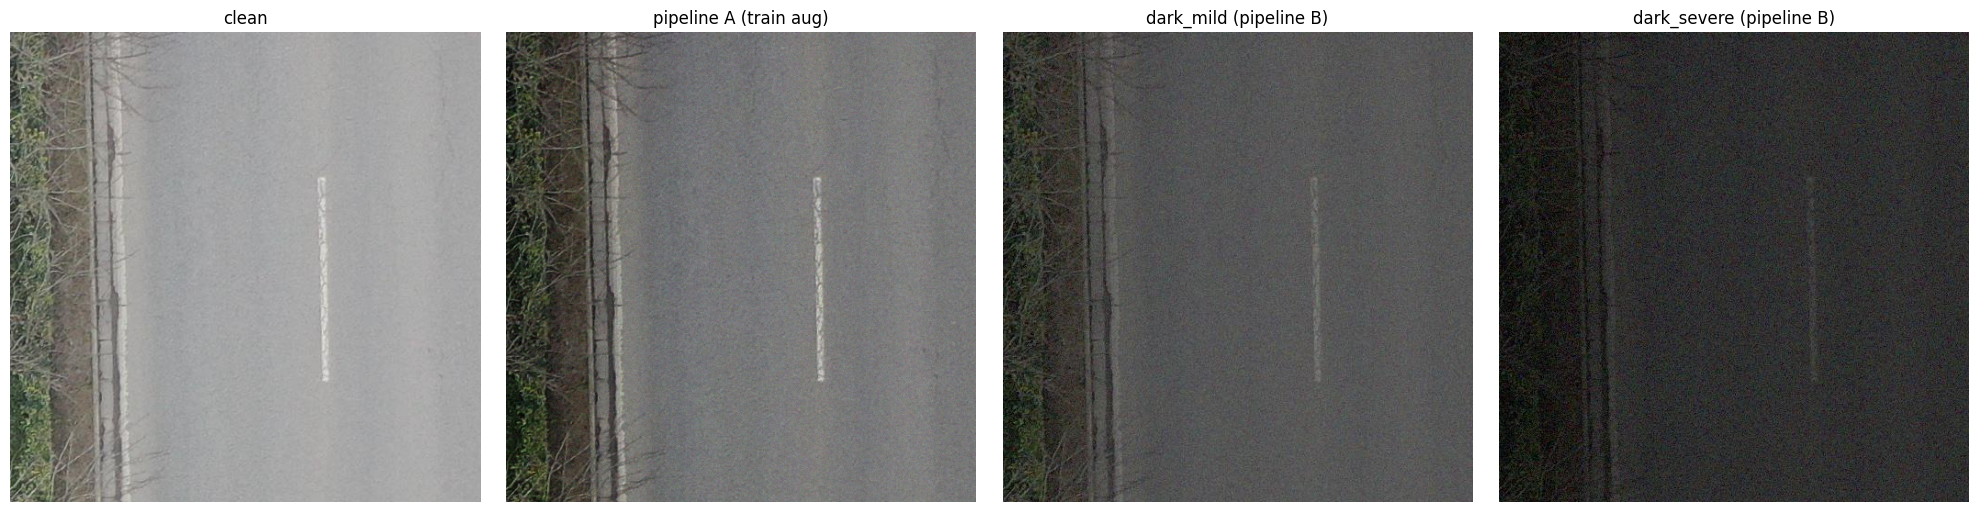

Saved /content/drive/MyDrive/rdd2022_project/figures/sample_grid_clean_aug_dark.png — inspect visually that boxes still align (labels are copied unchanged since both pipelines are photometric-only).


In [ ]:
# --- Sample grid: clean / pipeline A / dark_mild / dark_severe, same source image ---
import matplotlib.pyplot as plt

sample_name = sorted((OUT_DIR / 'images' / 'test').glob('*.jpg'))[0]
clean_img = np.array(PILImage.open(sample_name).convert('RGB'))

aug_a = build_pipeline_a(p=1.0)  # force-apply for the illustration grid
aug_a_img = aug_a(image=clean_img)['image']

mild_img = np.array(PILImage.open(DARK_MILD_DIR / 'images' / sample_name.name).convert('RGB'))
severe_img = np.array(PILImage.open(DARK_SEVERE_DIR / 'images' / sample_name.name).convert('RGB'))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img, title in zip(axes, [clean_img, aug_a_img, mild_img, severe_img],
                           ['clean', 'pipeline A (train aug)', 'dark_mild (pipeline B)', 'dark_severe (pipeline B)']):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
grid_path = PROJECT_DIR / 'figures' / 'sample_grid_clean_aug_dark.png'
plt.savefig(grid_path, dpi=150)
plt.show()
print("Saved", grid_path, "— inspect visually that boxes still align (labels are copied "
      "unchanged since both pipelines are photometric-only).")

In [ ]:
# Evaluate R1, R2 on all three test sets
for name, model in [('R1_baseline', r1_model), ('R2_cdl', r2_model)]:
    for split_name, yml in [('test_clean', DATA_YAML), ('test_dark_mild', DARK_MILD_YAML),
                             ('test_dark_severe', DARK_SEVERE_YAML)]:
        split_arg = 'test' if split_name == 'test_clean' else 'test'
        row = eval_variant(model, name, data_yaml=yml, split='test')
        row['test_set'] = split_name
        results_log.append(row)

checkpoint3_df = pd.DataFrame(results_log)
print(checkpoint3_df[checkpoint3_df.model.isin(['R1_baseline', 'R2_cdl'])]
      [['model', 'test_set', 'mAP50', 'mAP50-95']])

Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2445.2±800.0 MB/s, size: 72.0 KB)


val: Scanning /content/data/yolo/labels/test.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:06<00:00,  4.28it/s]


                   all        403        955      0.424      0.309      0.274      0.115
                   D00        231        453      0.439      0.342      0.306      0.133
                   D10        140        210       0.33      0.305      0.229     0.0735
                   D20        142        178      0.472      0.433      0.404      0.195
                   D40         66        114      0.455      0.158      0.159     0.0589
Speed: 0.6ms preprocess, 3.7ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/val3
{'model': 'R1_baseline', 'test_set': 'test', 'precision': 0.4240754684198452, 'recall': 0.30935106666883, 'mAP50': 0.2743394820852122, 'mAP50-95': 0.11533727086512575, 'AP50_D00': 0.30561878662626946, 'AP50_D10': 0.2288828887464712, 'AP50_D20': 0.40401404416931747, 'AP50_D40': 0.15884220879879063, 'params_M': 2.583}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.4±0

val: Scanning /content/drive/MyDrive/rdd2022_project/test_dark_mild/labels.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:08<00:00,  3.07it/s]


                   all        403        955      0.233      0.165      0.112     0.0446
                   D00        231        453      0.303      0.232      0.175     0.0707
                   D10        140        210      0.184      0.195      0.105     0.0325
                   D20        142        178      0.231       0.18      0.131     0.0594
                   D40         66        114      0.215     0.0526     0.0393     0.0156
Speed: 0.8ms preprocess, 3.9ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to runs/detect/val4
{'model': 'R1_baseline', 'test_set': 'test', 'precision': 0.233021918438799, 'recall': 0.16485825863863468, 'mAP50': 0.11248298352406214, 'mAP50-95': 0.04456104854686151, 'AP50_D00': 0.17507326037494278, 'AP50_D10': 0.10466736971293487, 'AP50_D20': 0.13091825840776763, 'AP50_D40': 0.03927304560060327, 'params_M': 2.583}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0

...

                   all        403        955      0.369      0.365      0.301      0.138
                   D00        231        453      0.367      0.411      0.334      0.154
                   D10        140        210      0.336       0.41      0.273     0.0971
                   D20        142        178      0.438      0.466      0.423      0.232
                   D40         66        114      0.334      0.175      0.173     0.0682
Speed: 0.7ms preprocess, 12.8ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to runs/detect/val6
{'model': 'R2_cdl', 'test_set': 'test', 'precision': 0.3685583571500981, 'recall': 0.3654626418341411, 'mAP50': 0.3008983920885051, 'mAP50-95': 0.13799264010617715, 'AP50_D00': 0.3336914958963294, 'AP50_D10': 0.2733865935094216, 'AP50_D20': 0.42307577119027934, 'AP50_D40': 0.17343970775799022, 'params_M': 3.618}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl summary: 180 layers, 3,618,084 param

val: Scanning /content/drive/MyDrive/rdd2022_project/test_dark_mild/labels.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:09<00:00,  2.68it/s]


                   all        403        955      0.232      0.177      0.109     0.0461
                   D00        231        453      0.273      0.227       0.16     0.0677
                   D10        140        210      0.178      0.248     0.0987     0.0325
                   D20        142        178      0.314      0.146      0.119      0.059
                   D40         66        114      0.162     0.0877     0.0561     0.0249
Speed: 0.7ms preprocess, 13.0ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/val7
{'model': 'R2_cdl', 'test_set': 'test', 'precision': 0.23178488970391642, 'recall': 0.17719470750691746, 'mAP50': 0.10855802604129738, 'mAP50-95': 0.046051578318434205, 'AP50_D00': 0.15997207939472924, 'AP50_D10': 0.09871002802412437, 'AP50_D20': 0.11948637822153345, 'AP50_D40': 0.056063618524802475, 'params_M': 3.618}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl summary: 180 layers, 3,618,08

val: Scanning /content/drive/MyDrive/rdd2022_project/test_dark_severe/labels.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:09<00:00,  2.66it/s]


                   all        403        955     0.0492     0.0441     0.0125    0.00469
                   D00        231        453     0.0766      0.053     0.0237    0.00914
                   D10        140        210     0.0541      0.081     0.0133     0.0041
                   D20        142        178     0.0595     0.0337     0.0125    0.00517
                   D40         66        114    0.00667    0.00877   0.000637   0.000331
Speed: 0.8ms preprocess, 13.3ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/val8
{'model': 'R2_cdl', 'test_set': 'test', 'precision': 0.04921178836844284, 'recall': 0.044103077098953204, 'mAP50': 0.012536571771311329, 'mAP50-95': 0.0046868882520152534, 'AP50_D00': 0.02369914411036155, 'AP50_D10': 0.013289632421118264, 'AP50_D20': 0.012520987282727263, 'AP50_D40': 0.0006365232710382346, 'params_M': 3.618}
         model          test_set     mAP50  mAP50-95
0  R1_baseline              test  0.274339  0.115337
1    

## Phase 4 — Extension runs (spec Section 10)

R3 adds pipeline A training augmentation to CDL. R4 adds Adaptive Gamma Enhancement (AGE) on top of that. AGE predicts an image-specific gamma value and applies illumination enhancement before the CDL backbone. Everything else — architecture for R3, data, training settings — stays identical to R2, per the cumulative-ladder rule.

In [ ]:
# R3: CDL + low-light training augmentation
install_pipeline_a(None)  # monkey-patches ultralytics.data.augment.Albumentations
#_ = time_one_epoch(YOLO(CDL_YAML_PATH), DATA_YAML, name='R3_cdl_aug')
r3_model = train_variant(CDL_YAML_PATH, 'R3_cdl_aug', load_coco=False)

[R3_cdl_aug] 60 epochs already completed.
[R3_cdl_aug] Loading best.pt.


In [ ]:
# Evaluate R3 on all three test sets
for split_name, yml in [('test_clean', DATA_YAML), ('test_dark_mild', DARK_MILD_YAML),
                         ('test_dark_severe', DARK_SEVERE_YAML)]:
    row = eval_variant(r3_model, 'R3_cdl_aug', data_yaml=yml, split='test')
    row['test_set'] = split_name
    results_log.append(row)

Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl summary: 180 layers, 3,618,084 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1466.1±365.2 MB/s, size: 77.9 KB)


val: Scanning /content/data/yolo/labels/test.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:09<00:00,  2.76it/s]


                   all        403        955      0.344      0.351      0.294      0.129
                   D00        231        453      0.347      0.408      0.312       0.14
                   D10        140        210      0.276      0.381       0.26     0.0982
                   D20        142        178      0.446        0.5      0.431      0.203
                   D40         66        114      0.305      0.114      0.173     0.0761
Speed: 0.6ms preprocess, 13.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/val9
{'model': 'R3_cdl_aug', 'test_set': 'test', 'precision': 0.343591446011146, 'recall': 0.3508439974107454, 'mAP50': 0.2942965355753634, 'mAP50-95': 0.129382859060553, 'AP50_D00': 0.31231400638849716, 'AP50_D10': 0.2599907445528344, 'AP50_D20': 0.4314647467420256, 'AP50_D40': 0.17341664461809642, 'params_M': 3.618}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl summary: 180 layers, 3,618,084 para

val: Scanning /content/drive/MyDrive/rdd2022_project/test_dark_mild/labels.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:09<00:00,  2.66it/s]


                   all        403        955      0.252      0.216      0.144     0.0622
                   D00        231        453      0.301      0.265      0.181     0.0766
                   D10        140        210      0.201      0.243       0.13     0.0465
                   D20        142        178      0.307       0.27      0.205     0.0979
                   D40         66        114      0.197     0.0877     0.0595     0.0279
Speed: 0.7ms preprocess, 14.0ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/val10
{'model': 'R3_cdl_aug', 'test_set': 'test', 'precision': 0.2516584109823437, 'recall': 0.2162850061756818, 'mAP50': 0.1441733700762247, 'mAP50-95': 0.06221359281284612, 'AP50_D00': 0.18140305665591416, 'AP50_D10': 0.1304258582778384, 'AP50_D20': 0.2053328640550949, 'AP50_D40': 0.05953170131605137, 'params_M': 3.618}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl summary: 180 layers, 3,618,084 

val: Scanning /content/drive/MyDrive/rdd2022_project/test_dark_severe/labels.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:10<00:00,  2.50it/s]


                   all        403        955     0.0883     0.0594     0.0283     0.0103
                   D00        231        453      0.146     0.0773     0.0403     0.0168
                   D10        140        210     0.0818      0.081     0.0324    0.00909
                   D20        142        178     0.0898     0.0618     0.0369     0.0137
                   D40         66        114      0.036     0.0175    0.00368    0.00167
Speed: 0.8ms preprocess, 14.4ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/val11
{'model': 'R3_cdl_aug', 'test_set': 'test', 'precision': 0.08829756560787458, 'recall': 0.05938917164180635, 'mAP50': 0.02830456246385022, 'mAP50-95': 0.010306232160750732, 'AP50_D00': 0.04025149486182264, 'AP50_D10': 0.03242753082318932, 'AP50_D20': 0.036856286912552515, 'AP50_D40': 0.0036829372578364166, 'params_M': 3.618}


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AGE(nn.Module):
    def __init__(self):
        super().__init__()

        self.gamma_net = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(16, 32, 3, 2, 1),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(32, 32, 3, 2, 1),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(32, 32, 3, 2, 1),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(32, 32, 3, 2, 1),
            nn.LeakyReLU(inplace=True),
        )

        self.fc1 = nn.Linear(2048, 64)
        self.fc2 = nn.Linear(64, 1)

        # Make AGE initially predict gamma = 1
        nn.init.zeros_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):

        x_small = F.interpolate(
            x,
            size=(256, 256),
            mode='bilinear',
            align_corners=False
        )

        gamma = self.gamma_net(x_small)
        gamma = gamma.flatten(1)

        gamma = F.leaky_relu(self.fc1(gamma))
        gamma = self.fc2(gamma)

        # Range: 0.5 to 1.5
        # With fc2 initialized to zero:
        # gamma = 0.5 + sigmoid(0) = 1.0
        gamma = 0.5 + torch.sigmoid(gamma)

        gamma = gamma.view(-1, 1, 1, 1)

        x = torch.clamp(x, 0, 1)

        # Initial AGE behaviour is exactly x^1 = x
        x = x ** gamma

        return x


import ultralytics.nn.tasks as tasks
tasks.AGE = AGE

In [ ]:
import ultralytics.nn.tasks as tasks
ns = getattr(tasks, '_cdl_patched_ns', None)
if ns is not None:
    ns['AGE'] = AGE
    print("Patched ns updated with AGE")
else:
    print("No patched ns found — register_custom_modules() hasn't run yet in this session")

Patched ns updated with AGE


In [ ]:
install_pipeline_a(None)
r4_model = train_variant(CDL_AGE_YAML_PATH, 'R4_cdl_age_aug_v2', load_coco=False)

[R4_cdl_age_aug_v2] 60 epochs already completed.
[R4_cdl_age_aug_v2] Loading best.pt.


In [ ]:
# Evaluate R4 on all three test sets
for split_name, yml in [
    ('test_clean', DATA_YAML),
    ('test_dark_mild', DARK_MILD_YAML),
    ('test_dark_severe', DARK_SEVERE_YAML)
]:
    row = eval_variant(
        r4_model,
        'R4_cdl_age_aug',
        data_yaml=yml,
        split='test'
    )
    row['test_set'] = split_name
    results_log.append(row)

results_df = pd.DataFrame(results_log).drop_duplicates(
    subset=['model', 'test_set'],
    keep='last'
)

results_df.to_csv(
    PROJECT_DIR / 'results_tables.csv',
    index=False
)

print(
    results_df.pivot(
        index='model',
        columns='test_set',
        values='mAP50'
    )
)

Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl_age summary: 192 layers, 3,782,117 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2015.4±521.8 MB/s, size: 83.4 KB)


val: Scanning /content/data/yolo/labels/test.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:09<00:00,  2.64it/s]


                   all        403        955      0.373      0.326      0.275      0.119
                   D00        231        453      0.386      0.364      0.298      0.137
                   D10        140        210      0.355        0.3      0.241     0.0882
                   D20        142        178      0.439      0.438        0.4      0.186
                   D40         66        114      0.314      0.202      0.159     0.0645
Speed: 0.6ms preprocess, 15.4ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/val12
{'model': 'R4_cdl_age_aug', 'test_set': 'test', 'precision': 0.3732652421803177, 'recall': 0.32604876093798746, 'mAP50': 0.27460199475168356, 'mAP50-95': 0.11881635018600925, 'AP50_D00': 0.29780270855858193, 'AP50_D10': 0.24132604133176666, 'AP50_D20': 0.4003284038113199, 'AP50_D40': 0.15895082530506566, 'params_M': 3.782}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl_age summary: 192 layers,

val: Scanning /content/drive/MyDrive/rdd2022_project/test_dark_mild/labels.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:10<00:00,  2.44it/s]


                   all        403        955      0.263      0.215      0.145     0.0615
                   D00        231        453      0.289      0.241      0.173     0.0758
                   D10        140        210      0.222      0.238      0.118     0.0391
                   D20        142        178      0.321      0.275      0.209     0.0989
                   D40         66        114      0.221      0.105     0.0792     0.0321
Speed: 0.6ms preprocess, 15.5ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/val13
{'model': 'R4_cdl_age_aug', 'test_set': 'test', 'precision': 0.2631075397388561, 'recall': 0.21481434910290834, 'mAP50': 0.14460101255773336, 'mAP50-95': 0.06148874144154948, 'AP50_D00': 0.17251443545651277, 'AP50_D10': 0.11803734105409089, 'AP50_D20': 0.20861957575554432, 'AP50_D40': 0.07923269796478552, 'params_M': 3.782}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl_age summary: 192 layers

val: Scanning /content/drive/MyDrive/rdd2022_project/test_dark_severe/labels.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:10<00:00,  2.44it/s]


                   all        403        955     0.0828     0.0657      0.028     0.0101
                   D00        231        453      0.165      0.102     0.0463      0.018
                   D10        140        210     0.0559     0.0714     0.0147    0.00444
                   D20        142        178       0.11     0.0899     0.0486     0.0172
                   D40         66        114          0          0    0.00233   0.000909
Speed: 0.7ms preprocess, 15.1ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/val14
{'model': 'R4_cdl_age_aug', 'test_set': 'test', 'precision': 0.0827669477942945, 'recall': 0.06571536643528607, 'mAP50': 0.027994690783240815, 'mAP50-95': 0.010145608712040167, 'AP50_D00': 0.04634617265638162, 'AP50_D10': 0.01469065215559782, 'AP50_D20': 0.0486131803355865, 'AP50_D40': 0.0023287579853973205, 'params_M': 3.782}
test_set            test  test_clean  test_dark_mild  test_dark_severe
model                                

## Phase 4b — R5: gated/brightness-constrained AGE (extension of R4)

R4's evaluation shows AGE improves dark-condition detection only marginally over
augmentation alone (R3), while measurably reducing `test_clean` performance relative to
R2/R3. The likely cause: AGE's gamma correction is applied unconditionally to every image,
regardless of how bright it already is, and the only training signal steering it toward
identity behavior on clean images is weak, indirect pressure from the detection loss — not
an explicit constraint.

R5 tests a targeted fix: **gate the predicted gamma by a brightness estimate**, so
correction strength is scaled by how dark the input actually is. A cheap brightness proxy
(mean pixel value of the downsampled 256×256 crop, computed under `no_grad`) drives a
`darkness_gate ∈ [0, 1]` that blends the network's predicted gamma toward exactly 1.0
(identity) as the image gets brighter:

gamma = 1.0 + darkness_gate * (gamma_raw - 1.0)


This is a structural constraint, not a loss-based incentive — on a bright image the
network's raw prediction is multiplied toward zero contribution regardless of what the
gamma-predicting subnetwork has learned, so near-identity behavior on clean images is
guaranteed by construction rather than hoped for via training dynamics. Everything else
(CDL backbone, pipeline-A augmentation, training settings) is identical to R4, isolating
gating as the single variable under test.

[DECISION] `brightness_thresh = 0.4` — chosen after inspecting the brightness distribution
of un-augmented training images (spec Checkpoint-style sanity check: mean ≈ 0.55, range
≈ 0.27–0.72), so the gate stays near 0 for typical daytime images and rises toward 1 as
pipeline-A's darkened training images and real dark test images fall below this threshold.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AGE(nn.Module):
    def __init__(self, brightness_thresh=0.4):
        super().__init__()
        self.brightness_thresh = brightness_thresh

        self.gamma_net = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(16, 32, 3, 2, 1),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(32, 32, 3, 2, 1),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(32, 32, 3, 2, 1),
            nn.LeakyReLU(inplace=True),

            nn.Conv2d(32, 32, 3, 2, 1),
            nn.LeakyReLU(inplace=True),
        )

        self.fc1 = nn.Linear(2048, 64)
        self.fc2 = nn.Linear(64, 1)

        # Make AGE initially predict gamma = 1
        nn.init.zeros_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        x_small = F.interpolate(
            x,
            size=(256, 256),
            mode='bilinear',
            align_corners=False
        )

        # Brightness-gated correction: estimate brightness, blend predicted gamma
        # toward identity (1.0) on well-lit images so AGE only acts where needed.
        with torch.no_grad():
            brightness = x_small.mean(dim=(1, 2, 3), keepdim=True)
            darkness_gate = torch.clamp(1 - brightness / self.brightness_thresh, 0, 1)

        gamma = self.gamma_net(x_small)
        gamma = gamma.flatten(1)

        gamma = F.leaky_relu(self.fc1(gamma))
        gamma = self.fc2(gamma)

        gamma_raw = 0.5 + torch.sigmoid(gamma)
        gamma_raw = gamma_raw.view(-1, 1, 1, 1)

        gamma = 1.0 + darkness_gate * (gamma_raw - 1.0)

        x = torch.clamp(x, 0, 1)
        x = x ** gamma

        return x


import ultralytics.nn.tasks as tasks
ns = getattr(tasks, '_cdl_patched_ns', None)
if ns is not None:
    ns['AGE'] = AGE
tasks.AGE = AGE

In [ ]:
CDL_AGE_GATED_YAML_TEXT = r'''
nc: 4
scales:
  n: [0.50, 0.25, 1024]

backbone:
  - [-1, 1, AGE,        []]                # 0  gated adaptive gamma enhancement
  - [-1, 1, ConvSmart,  [64, 3, 2]]         # 1  P1/2
  - [-1, 1, ConvSmart,  [128, 3, 2]]        # 2  P2/4
  - [-1, 2, C3k2,       [256, False, 0.25]] # 3
  - [-1, 1, ConvSmart,  [256, 3, 2]]        # 4  P3/8
  - [-1, 2, C3k2,       [512, False, 0.25]] # 5
  - [-1, 1, ConvSmart,  [512, 3, 2]]        # 6  P4/16
  - [-1, 2, C3k2,       [512, True]]        # 7
  - [-1, 1, ConvSmart,  [1024, 3, 2]]       # 8  P5/32
  - [-1, 2, C3k2,       [1024, True]]       # 9
  - [-1, 1, SPPF,       [1024, 5]]          # 10
  - [-1, 2, C2PSA,      [1024]]             # 11
  - [-1, 1, DSA,        [1024]]             # 12

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 13
  - [[-1, 7], 1, Concat, [1]]                   # 14
  - [-1, 2, C3k2, [512, False]]                 # 15

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 16
  - [[-1, 5], 1, Concat, [1]]                   # 17
  - [-1, 2, C3k2, [256, False]]                 # 18

  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]  # 19
  - [[-1, 3], 1, Concat, [1]]                   # 20
  - [-1, 2, C3k2, [128, False]]                 # 21

  - [-1, 1, ConvSmart, [128, 3, 2]]             # 22
  - [[-1, 18], 1, Concat, [1]]                  # 23
  - [-1, 2, C3k2, [256, False]]                 # 24

  - [-1, 1, ConvSmart, [256, 3, 2]]             # 25
  - [[-1, 15], 1, Concat, [1]]                  # 26
  - [-1, 2, C3k2, [512, False]]                 # 27

  - [-1, 1, ConvSmart, [512, 3, 2]]             # 28
  - [[-1, 12], 1, Concat, [1]]                  # 29
  - [-1, 2, C3k2, [1024, True]]                 # 30

  - [[21, 24, 27, 30], 1, Detect, [nc]]
'''
CDL_AGE_GATED_YAML_PATH = '/content/cdl_age_gated.yaml'
with open(CDL_AGE_GATED_YAML_PATH, 'w') as f:
    f.write(CDL_AGE_GATED_YAML_TEXT)

In [ ]:
# R5: CDL + low-light training augmentation + brightness-gated AGE
install_pipeline_a(None)
r5_model = train_variant(CDL_AGE_GATED_YAML_PATH, 'R5_cdl_gated_age_aug', load_coco=False)

[R5_cdl_gated_age_aug] 60 epochs already completed.
[R5_cdl_gated_age_aug] Loading best.pt.


In [ ]:
for split_name, yml in [
    ('test_clean', DATA_YAML),
    ('test_dark_mild', DARK_MILD_YAML),
    ('test_dark_severe', DARK_SEVERE_YAML)
]:
    row = eval_variant(
        r5_model,
        'R5_cdl_gated_age_aug',
        data_yaml=yml,
        split='test'
    )
    row['test_set'] = split_name
    results_log.append(row)

Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl_age_r5 summary: 192 layers, 3,782,117 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1838.8±981.7 MB/s, size: 495.9 KB)


val: Scanning /content/data/yolo/labels/test.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:11<00:00,  2.33it/s]


                   all        403        955      0.365      0.339      0.302      0.128
                   D00        231        453      0.402      0.402      0.326      0.152
                   D10        140        210      0.315      0.357       0.28     0.0949
                   D20        142        178      0.459      0.476      0.442      0.205
                   D40         66        114      0.285      0.123      0.159     0.0619
Speed: 0.7ms preprocess, 16.1ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to runs/detect/val18
{'model': 'R5_cdl_gated_age_aug', 'test_set': 'test', 'precision': 0.3649050372928245, 'recall': 0.33942698100043384, 'mAP50': 0.3017981587263246, 'mAP50-95': 0.1284021175576905, 'AP50_D00': 0.32594909147562123, 'AP50_D10': 0.2795492582718429, 'AP50_D20': 0.4423163841555048, 'AP50_D40': 0.15937790100232943, 'params_M': 3.782}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl_age_r5 summary: 192 l

val: Scanning /content/drive/MyDrive/rdd2022_project/test_dark_mild/labels.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:11<00:00,  2.35it/s]


                   all        403        955      0.359      0.187      0.156     0.0647
                   D00        231        453      0.364      0.243      0.185     0.0806
                   D10        140        210      0.248      0.219      0.136     0.0422
                   D20        142        178      0.339      0.197      0.195     0.0899
                   D40         66        114      0.487     0.0877      0.106     0.0461
Speed: 0.7ms preprocess, 15.7ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/detect/val19
{'model': 'R5_cdl_gated_age_aug', 'test_set': 'test', 'precision': 0.35935625638567736, 'recall': 0.1865554344600992, 'mAP50': 0.1556465236389497, 'mAP50-95': 0.0646960564823801, 'AP50_D00': 0.18531833424834482, 'AP50_D10': 0.13606478135480676, 'AP50_D20': 0.19528962035740718, 'AP50_D40': 0.10591335859524006, 'params_M': 3.782}
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl_age_r5 summary: 192

val: Scanning /content/drive/MyDrive/rdd2022_project/test_dark_severe/labels.cache... 403 images, 0 backgrounds, 0 corrupt: 100%|██████████| 403/403 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:11<00:00,  2.31it/s]


                   all        403        955       0.11     0.0651     0.0331     0.0127
                   D00        231        453      0.164     0.0817      0.044     0.0186
                   D10        140        210     0.0792     0.0857     0.0295    0.00908
                   D20        142        178      0.162     0.0843     0.0546     0.0214
                   D40         66        114     0.0338    0.00877    0.00414     0.0019
Speed: 0.8ms preprocess, 14.8ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to runs/detect/val20
{'model': 'R5_cdl_gated_age_aug', 'test_set': 'test', 'precision': 0.10957879246456498, 'recall': 0.06510839566361398, 'mAP50': 0.033072899965172556, 'mAP50-95': 0.012749874202732474, 'AP50_D00': 0.04404894856826829, 'AP50_D10': 0.02945956552904922, 'AP50_D20': 0.05464019975446713, 'AP50_D40': 0.0041428860089055795, 'params_M': 3.782}


## Phase 5 — Analysis and report (spec Section 8, agent brief Section 3)

Produces every table/figure the brief's deliverables list requires: main results table,
per-class AP, per-country mAP, degradation table, small-defect subset, qualitative grid,
training curves, and the limitations section.

In [ ]:
# 1. Main table: R1-R4 x test set, + GFLOPs + FPS (all measured on the same GPU/session)
import copy

def measure_gflops(model):
    try:
        return model.model.info(verbose=False)[3]  # ultralytics info() returns (layers, params, gradients, GFLOPs)
    except Exception:
        return float('nan')

def measure_fps(model, n_warmup=10, n_timed=50, imgsz=640):
    model.model.eval()
    x = torch.randn(1, 3, imgsz, imgsz).to(next(model.model.parameters()).device)
    with torch.no_grad():
        for _ in range(n_warmup):
            model.model(x)
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        t0 = time.time()
        for _ in range(n_timed):
            model.model(x)
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        dt = time.time() - t0
    return n_timed / dt

variant_models = {'R1_baseline': r1_model, 'R2_cdl': r2_model, 'R3_cdl_aug': r3_model,
                   'R4_cdl_age_aug': r4_model, 'R5_cdl_gated_age_aug': r5_model}

perf_rows = []
for name, model in variant_models.items():
    perf_rows.append({
        'model': name,
        'GFLOPs': measure_gflops(model),
        'FPS': round(measure_fps(model), 1),
    })
perf_df = pd.DataFrame(perf_rows)
print(perf_df)

main_table = results_df.merge(perf_df, on='model', how='left')
main_table.to_csv(PROJECT_DIR / 'main_results_table.csv', index=False)
main_table

                  model  GFLOPs   FPS
0           R1_baseline     NaN  98.6
1                R2_cdl     NaN  34.5
2            R3_cdl_aug     NaN  65.5
3        R4_cdl_age_aug     NaN  64.3
4  R5_cdl_gated_age_aug     NaN  64.5


,model,test_set,precision,recall,mAP50,mAP50-95,AP50_D00,AP50_D10,AP50_D20,AP50_D40,params_M,GFLOPs,FPS
0,R1_baseline,test,0.424075,0.309351,0.274339,0.115337,0.305619,0.228883,0.404014,0.158842,2.583,NaN,98.6
1,R2_cdl,test,0.368558,0.365463,0.300898,0.137993,0.333691,0.273387,0.423076,0.173440,3.618,NaN,34.5
2,R1_baseline,test_clean,0.424075,0.309351,0.274339,0.115337,0.305619,0.228883,0.404014,0.158842,2.583,NaN,98.6
3,R1_baseline,test_dark_mild,0.233022,0.164858,0.112483,0.044561,0.175073,0.104667,0.130918,0.039273,2.583,NaN,98.6
4,R1_baseline,test_dark_severe,0.050203,0.031620,0.008478,0.003091,0.017957,0.010073,0.005420,0.000463,2.583,NaN,98.6
5,R2_cdl,test_clean,0.368558,0.365463,0.300898,0.137993,0.333691,0.273387,0.423076,0.173440,3.618,NaN,34.5
6,R2_cdl,test_dark_mild,0.231785,0.177195,0.108558,0.046052,0.159972,0.098710,0.119486,0.056064,3.618,NaN,34.5
7,R2_cdl,test_dark_severe,0.049212,0.044103,0.012537,0.004687,0.023699,0.013290,0.012521,0.000637,3.618,NaN,34.5
8,R3_cdl_aug,test_clean,0.343591,0.350844,0.294297,0.129383,0.312314,0.259991,0.431465,0.173417,3.618,NaN,65.5
9,R3_cdl_aug,test_dark_mild,0.251658,0.216285,0.144173,0.062214,0.181403,0.130426,0.205333,0.059532,3.618,NaN,65.5


In [ ]:
# 2. Per-class AP@0.5 table (already in results_df; pivot for readability)
model_order = ['R1_baseline', 'R2_cdl', 'R3_cdl_aug', 'R4_cdl_age_aug', 'R5_cdl_gated_age_aug']
test_set_order = ['test_clean', 'test_dark_mild', 'test_dark_severe']

per_class_table = results_df.pivot_table(
    index=['model', 'test_set'],
    values=['AP50_D00', 'AP50_D10', 'AP50_D20', 'AP50_D40'],
)
per_class_table = per_class_table.reindex(
    pd.MultiIndex.from_product([model_order, test_set_order], names=['model', 'test_set'])
)
per_class_table.to_csv(PROJECT_DIR / 'per_class_ap_table.csv')
per_class_table

AP50_D00  AP50_D10  AP50_D20  AP50_D40
model                test_set                                                
R1_baseline          test_clean        0.305619  0.228883  0.404014  0.158842
                     test_dark_mild    0.175073  0.104667  0.130918  0.039273
                     test_dark_severe  0.017957  0.010073  0.005420  0.000463
R2_cdl               test_clean        0.333691  0.273387  0.423076  0.173440
                     test_dark_mild    0.159972  0.098710  0.119486  0.056064
                     test_dark_severe  0.023699  0.013290  0.012521  0.000637
R3_cdl_aug           test_clean        0.312314  0.259991  0.431465  0.173417
                     test_dark_mild    0.181403  0.130426  0.205333  0.059532
                     test_dark_severe  0.040251  0.032428  0.036856  0.003683
R4_cdl_age_aug       test_clean        0.297803  0.241326  0.400328  0.158951
                     test_dark_mild    0.172514  0.118037  0.208620  0.079233
                     test_dark_severe  0.046346  0.014691  0.048613  0.002329
R5_cdl_gated_age_aug test_clean        0.325949  0.279549  0.442316  0.159378
                     test_dark_mild    0.185318  0.136065  0.195290  0.105913
                     test_dark_severe  0.044049  0.029460  0.054640  0.004143

In [ ]:
# 3. Per-country mAP on test_clean — group by the source prefix baked into each filename
# during Phase 0 conversion (f"{src}_{img_path.name}"). Run for both R2 (CDL) and R5
# (CDL + Aug + gated AGE) side by side for comparison.
def per_country_map(model, data_yaml=DATA_YAML):
    rows = []
    for src in SOURCES:
        tmp_dir = Path(f'/content/data/tmp_{src}')
        (tmp_dir / 'images').mkdir(parents=True, exist_ok=True)
        (tmp_dir / 'labels').mkdir(parents=True, exist_ok=True)
        matches = list((OUT_DIR / 'images' / 'test').glob(f'{src}_*.jpg'))
        if not matches:
            continue
        for img_path in matches:
            shutil.copy(img_path, tmp_dir / 'images' / img_path.name)
            lbl = OUT_DIR / 'labels' / 'test' / (img_path.stem + '.txt')
            if lbl.exists():
                shutil.copy(lbl, tmp_dir / 'labels' / lbl.name)
        yml_text = f"path: {tmp_dir}\ntrain: images\nval: images\ntest: images\nnames:\n  0: D00\n  1: D10\n  2: D20\n  3: D40\n"
        yml_path = f'/content/data/tmp_{src}.yaml'
        with open(yml_path, 'w') as f:
            f.write(yml_text)
        res = model.val(data=yml_path, split='test')
        rows.append({'country': src, 'n_images': len(matches), 'mAP50': float(res.box.map50)})
    return pd.DataFrame(rows)

country_table = per_country_map(r2_model)  # R2 (CDL)
country_table.to_csv(PROJECT_DIR / 'per_country_map_test_clean_r2.csv', index=False)

country_table_r5 = per_country_map(r5_model)  # R5 (CDL + Aug + gated AGE)
country_table_r5.to_csv(PROJECT_DIR / 'per_country_map_test_clean_r5.csv', index=False)

country_compare = country_table.merge(
    country_table_r5, on=['country', 'n_images'], suffixes=('_R2', '_R5')
)
country_compare['delta'] = country_compare['mAP50_R5'] - country_compare['mAP50_R2']
country_compare.to_csv(PROJECT_DIR / 'per_country_map_R2_vs_R5.csv', index=False)
country_compare

Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl summary: 180 layers, 3,618,084 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2259.5±1104.7 MB/s, size: 108.3 KB)


val: Scanning /content/data/tmp_Japan/labels.cache... 133 images, 0 backgrounds, 0 corrupt: 100%|██████████| 133/133 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:05<00:00,  1.58it/s]


                   all        133        281      0.432      0.388      0.354      0.159
                   D00         46         74        0.4      0.432      0.366      0.171
                   D10         35         57       0.47      0.404      0.368      0.112
                   D20         83        108      0.433        0.5      0.459      0.258
                   D40         27         42      0.424      0.214      0.222     0.0957
Speed: 8.2ms preprocess, 14.4ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to runs/detect/val28
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl summary: 180 layers, 3,618,084 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1412.9±610.3 MB/s, size: 63.5 KB)


val: Scanning /content/data/tmp_India/labels.cache... 55 images, 0 backgrounds, 0 corrupt: 100%|██████████| 55/55 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.76it/s]


                   all         55        119      0.336       0.25      0.277      0.118
                   D00         22         30      0.209     0.0667      0.112     0.0419
                   D20         31         35      0.473       0.54      0.559      0.239
                   D40         24         54      0.327      0.144       0.16     0.0723
Speed: 7.6ms preprocess, 14.5ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/detect/val29
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl summary: 180 layers, 3,618,084 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1189.1±445.4 MB/s, size: 68.3 KB)


...

val: Scanning /content/data/tmp_China_MotorBike/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100%|██████████| 33/33 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  2.05it/s]


                   all         33         82      0.491      0.393      0.389      0.163
                   D00         25         46       0.47      0.478       0.47       0.19
                   D10         15         21       0.48      0.395      0.512      0.194
                   D20          8         10       0.52        0.5      0.416      0.222
                   D40          4          5      0.493      0.197      0.158     0.0452
Speed: 6.8ms preprocess, 17.0ms inference, 0.1ms loss, 3.2ms postprocess per image
Results saved to runs/detect/val40
Ultralytics 8.3.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
cdl_age_r5 summary: 192 layers, 3,782,117 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1452.7±303.9 MB/s, size: 63.0 KB)


val: Scanning /content/data/tmp_China_Drone/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100%|██████████| 33/33 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  2.18it/s]


                   all         33         53      0.358      0.617      0.374      0.196
                   D00         17         26      0.309      0.551      0.413      0.211
                   D10         15         19      0.287      0.632      0.336      0.184
                   D20          6          7      0.436      0.286      0.248      0.089
                   D40          1          1      0.399          1      0.497      0.298
Speed: 8.2ms preprocess, 16.4ms inference, 0.0ms loss, 4.9ms postprocess per image
Results saved to runs/detect/val41


,country,n_images,mAP50_R2,mAP50_R5,delta
0,Japan,133,0.353630,0.363462,0.009832
1,India,55,0.277089,0.255248,-0.021841
2,Czech,18,0.327322,0.563776,0.236455
3,Norway,49,0.214052,0.119065,-0.094987
4,United_States,82,0.336048,0.332292,-0.003756
5,China_MotorBike,33,0.415495,0.389123,-0.026372
6,China_Drone,33,0.341677,0.373530,0.031853


In [ ]:
# 4. Degradation table: mAP50 drop from clean to dark_mild / dark_severe, per model
pivot = results_df.pivot_table(index='model', columns='test_set', values='mAP50')
degradation = pd.DataFrame({
    'test_clean': pivot.get('test_clean'),
    'drop_to_mild': pivot.get('test_clean') - pivot.get('test_dark_mild'),
    'drop_to_severe': pivot.get('test_clean') - pivot.get('test_dark_severe'),
})
degradation.to_csv(PROJECT_DIR / 'degradation_table.csv')
degradation

,test_clean,drop_to_mild,drop_to_severe
model,,,
R1_baseline,0.274339,0.161856,0.265861
R2_cdl,0.300898,0.192340,0.288362
R3_cdl_aug,0.294297,0.150123,0.265992
R4_cdl_age_aug,0.274602,0.130001,0.246607
R5_cdl_gated_age_aug,0.301798,0.146152,0.268725


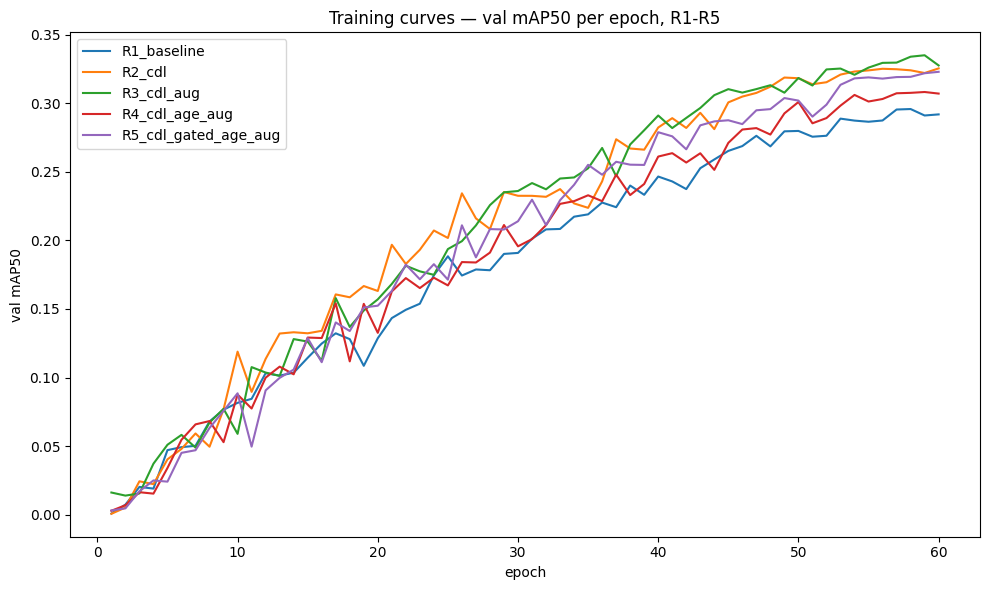

Saved /content/drive/MyDrive/rdd2022_project/figures/training_curves.png


In [ ]:
#5 Plotting Training Curves
import pandas as pd
import matplotlib.pyplot as plt

curve_runs = {
    'R1_baseline_scratch': 'R1_baseline',
    'R2_cdl_scratch': 'R2_cdl',
    'R3_cdl_aug': 'R3_cdl_aug',
    'R4_cdl_age_aug_v2': 'R4_cdl_age_aug',
    'R5_cdl_gated_age_aug': 'R5_cdl_gated_age_aug',
}

fig, ax = plt.subplots(figsize=(10, 6))
for folder_name, label in curve_runs.items():
    csv_path = PROJECT_DIR / 'runs' / folder_name / 'results.csv'
    if not csv_path.exists():
        print(f"no results.csv for {label} (looked in {folder_name}), skipping curve")
        continue
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    map_col = [c for c in df.columns if 'mAP50' in c and '95' not in c][0]
    ax.plot(df['epoch'], df[map_col], label=label)

ax.set_xlabel('epoch')
ax.set_ylabel('val mAP50')
ax.set_title('Training curves — val mAP50 per epoch, R1-R5')
ax.legend()
plt.tight_layout()
curves_path = PROJECT_DIR / 'figures' / 'training_curves.png'
plt.savefig(curves_path, dpi=150)
plt.show()
print("Saved", curves_path)

## Limitations (compiled for `REPORT.md`)

- **Single seed per model.** Run-to-run variance was not measured. Differences of about 1 mAP50 or less (e.g. R3 vs R5 on the dark sets) are not statistically established.
- **Small test set:** 403 images / 955 instances. Per-class and per-country breakdowns are especially noisy (Czech has 18 test images).
- **Design decision informed by test results:** R5's brightness gate and threshold were designed after inspecting R4's test-set results. The threshold (0.4) was set from training-image brightness statistics, but the decision to add a gate was motivated by R4's clean-set regression.
- **Data split:** contiguous-block split per country reduces but does not eliminate near-duplicate-frame leakage.
- **Reduced scale:** ~4,000 images (vs the paper's 20k+), 60 epochs, trained from scratch. Absolute mAP (~30) is not comparable to the paper's RDD2022 figures (~60).
- **Partial weight transfer:** not applicable in the final runs (all trained from scratch), but CDL layers have no COCO counterpart.
- **Synthetic darkness:** pipeline B is a physically motivated proxy, not real night photography. Pipeline A (train) and B (test) are both darkening + noise, which somewhat favours augmented models (R3-R5).
- **AGE deviates from TinyDark-YOLO:** gamma range [0.5, 1.5] with zero-initialized final FC (identity at start) instead of [0.01, 0.99], because the paper's range gave noisy early training in this setup. AGE here is an AGE-style module, not a faithful reproduction.
- **Gated AGE (R5) is an original extension:** the brightness gate is not from the source paper.
- **Non-determinism:** training is not fully deterministic despite fixed seeds.
- Every `[DECISION]` is in `decisions_log.md`; copy that table into the report verbatim.
- Paper inconsistencies (spec Section 9) are not reproduced here.

In [ ]:
report_md = f'''# YOLOv11n-CDL Reproduction + Low-Light Robustness Extension — Report

## Research question
Does CDL's design (ConvSmart + DSA + P2 head) make YOLOv11n more robust to low light than
stock YOLOv11n, does low-light training augmentation improve it, and can an AGE-style learned
gamma correction add further robustness, with or without a brightness gate?

## Method
See `common.py`, `cdl.yaml`, `cdl_age.yaml`, `cdl_age_gated.yaml` on Drive and
`YOLOv11n-CDL_reconstruction_spec.md`. Ladder: R1 baseline, R2 CDL, R3 CDL+aug,
R4 CDL+aug+naive AGE, R5 CDL+aug+gated AGE. Single seed per model.

## Results (mAP@0.5, test)
| Model | clean | dark_mild | dark_severe |
|---|---|---|---|
| R1 baseline | 27.4 | 11.2 | 0.8 |
| R2 CDL | 30.1 | 10.9 | 1.3 |
| R3 CDL + aug | 29.4 | 14.4 | 2.8 |
| R4 + naive AGE | 27.5 | 14.5 | 2.8 |
| R5 + gated AGE | 30.2 | 15.6 | 3.3 |

Full tables: `main_results_table.csv`, `per_class_ap_table.csv`, `degradation_table.csv`,
`per_country_map_R2_vs_R5.csv`, `figures/training_curves.png`.

## Analysis
- **CDL vs baseline:** R2 improves clean mAP50 by 2.7 points (27.4 -> 30.1), consistent in direction
  with the paper, but gives no low-light benefit on its own (mild: 10.9 vs 11.2).
- **Augmentation:** low-light training augmentation is the largest single improvement in dark
  conditions (R3 vs R2: mild +3.5, severe +1.5) at a small clean cost (-0.7).
- **Naive AGE (R4):** no dark-condition gain over R3 and lower clean mAP (27.5 vs 29.4).
  A likely cause is that gamma is applied unconditionally, including to well-lit images.
- **Gated AGE (R5):** restores clean mAP to the level of R2/R3 (30.2) and scores slightly higher than R3 on
  both dark sets (+1.1 mild, +0.5 severe). With one seed and 403 test images, these gaps are within
  plausible run-to-run variance, so R5 should be read as comparable to R3 on dark data rather than a
  confirmed improvement. The clearer result is R4 -> R5: the gate removes the clean-image regression.

## Limitations
See the Limitations cell and `decisions_log.md`.
'''
with open(PROJECT_DIR / 'REPORT.md', 'w') as f:
    f.write(report_md)
print("Wrote REPORT.md to Drive.")

Wrote REPORT.md to Drive.
